# Drift Detection — Offset View

This notebook is an extension of `Drift_Detection.ipynb` that **offsets every value by `NUMERIC_FINAL_VALUE`**,
so the measured value is always anchored at **0**.

| Column | Offset transform |
|---|---|
| `NUMERIC_FINAL_VALUE` | → **0** (always) |
| `INTERNAL_TARGET_VALUE` | → `target − value` |
| `INTERNAL_MAX_WARNING_VALUE` | → `max_warn − value` |
| `INTERNAL_MIN_WARNING_VALUE` | → `min_warn − value` |

**Why this helps**  
Analytes can span vastly different absolute scales (e.g. Cu ≈ 1 500, Bi ≈ 0.7). After offsetting, all analytes
share the same zero reference — the measurement itself — so drift patterns can be compared side-by-side.

Drift is visible as the **offset target drifting away from 0** and/or the **offset warning bounds converging toward 0**.

**Drift detection logic** is identical to `Drift_Detection.ipynb` (rolling normalised deviation against warning bounds),
because normalisation is scale-invariant.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

## 1. Load Data

In [2]:
df = pd.read_csv("Data/ResultSet.csv")
df.columns = [c.strip().upper() for c in df.columns]

for col in ["NUMERIC_FINAL_VALUE", "INTERNAL_TARGET_VALUE",
            "INTERNAL_MAX_WARNING_VALUE", "INTERNAL_MIN_WARNING_VALUE",
            "INTERNAL_MAX_VALUE", "INTERNAL_MIN_VALUE"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["ANALYSED_DATE"] = pd.to_datetime(df["ANALYSED_DATE"], errors="coerce")

print(f"Loaded {len(df):,} rows")
print("Available STD_LOT_CODEs:")
print(df[df["ANALYTICAL_TYPE"] == "Standard"]["STD_LOT_CODE"].value_counts().to_string())

Loaded 99,999 rows
Available STD_LOT_CODEs:
STD_LOT_CODE
Sample        6958
OREAS_905     5661
OREAS_62F     5551
OREAS_501C    5410
OREAS_503C    4305
OREAS_624     4299
OREAS_522     1122
OREAS_139     1013
OREAS_908      735
OREAS_524      519
OREAS_503D     225
OREAS_351      205
OREAS_20A      164
OREAS_98       157
OREAS_623      136
OREAS_621       61
OREAS_505       58
OREAS_520       26
OREAS_136       25
OREAS_38        21
OREAS_45F       10
OREAS_45H       10
OREAS_622       10
OREAS_605        6


## 2. Configuration

In [3]:
# ── INPUT ────────────────────────────────────────────────────────────────────
STD_LOT_CODE = "OREAS_905"   # change to any STD_LOT_CODE from the list above

# ── DRIFT PARAMETERS ─────────────────────────────────────────────────────────
ROLLING_WINDOW       = 10   # observations for rolling mean
DRIFT_THRESHOLD      = 0.5  # fraction of the way from target to warning bound
CONSECUTIVE_REQUIRED = 3    # consecutive rolling-mean breaches to confirm drift

## 3. Offset Transform + Drift Detection

In [4]:
STATUS_COLORS = {
    "Pass"               : "#1565C0",
    "UpperWarning"       : "#EF6C00",
    "LowerWarning"       : "#FF8F00",
    "UpperFailure"       : "#C62828",
    "LowerFailure"       : "#AD1457",
    "IgnoredUpperFailure": "#9E9E9E",
    "IgnoredLowerFailure": "#BDBDBD",
}

def _fmt_date(dt):
    return dt.strftime("%Y-%m-%d") if pd.notna(dt) else "—"


def apply_offset(adf: pd.DataFrame) -> pd.DataFrame:
    """Subtract NUMERIC_FINAL_VALUE from the four key columns, row-wise."""
    adf = adf.copy()
    v = adf["NUMERIC_FINAL_VALUE"]
    adf["OFFSET_VALUE"]    = 0.0                                         # always 0
    adf["OFFSET_TARGET"]   = adf["INTERNAL_TARGET_VALUE"]   - v
    adf["OFFSET_MAX_WARN"] = adf["INTERNAL_MAX_WARNING_VALUE"] - v
    adf["OFFSET_MIN_WARN"] = adf["INTERNAL_MIN_WARNING_VALUE"] - v
    if "INTERNAL_MAX_VALUE" in adf.columns:
        adf["OFFSET_MAX_FAIL"] = adf["INTERNAL_MAX_VALUE"] - v
    if "INTERNAL_MIN_VALUE" in adf.columns:
        adf["OFFSET_MIN_FAIL"] = adf["INTERNAL_MIN_VALUE"] - v
    return adf


def detect_drift_offset(df: pd.DataFrame,
                        std_lot_code: str,
                        rolling_window: int = 10,
                        drift_threshold: float = 0.5,
                        consecutive_required: int = 3) -> tuple[pd.DataFrame, dict]:
    """
    Detect drift for all analytes within a given STD_LOT_CODE.
    All values are offset by NUMERIC_FINAL_VALUE before analysis.

    Returns
    -------
    summary      : DataFrame — one row per analyte
    analyte_data : dict      — {analyte: per-observation DataFrame with offset columns}
    """
    required_cols = [
        "ANALYTICAL_TYPE", "STD_LOT_CODE", "ANALYTE_CODE", "ANALYSED_DATE",
        "NUMERIC_FINAL_VALUE", "INTERNAL_TARGET_VALUE",
        "INTERNAL_MAX_WARNING_VALUE", "INTERNAL_MIN_WARNING_VALUE",
    ]

    lot_df = (
        df[
            (df["ANALYTICAL_TYPE"] == "Standard") &
            (df["STD_LOT_CODE"] == std_lot_code)
        ]
        .dropna(subset=required_cols)
        .copy()
    )

    if lot_df.empty:
        raise ValueError(f"No Standard rows found for STD_LOT_CODE='{std_lot_code}'")

    summary_rows = []
    analyte_data = {}

    for analyte, adf in lot_df.groupby("ANALYTE_CODE"):
        adf = adf.sort_values("ANALYSED_DATE").reset_index(drop=True)
        adf = apply_offset(adf)

        # ── Normalised deviation (scale-invariant; identical to base notebook) ─
        # In offset space: value=0, target=OFFSET_TARGET, bounds=OFFSET_MAX/MIN_WARN
        # norm_dev = (0 - OFFSET_TARGET) / (OFFSET_MAX/MIN_WARN - OFFSET_TARGET)
        #          = (value - target) / (warn_bound - target)  ← same formula
        target   = adf["INTERNAL_TARGET_VALUE"]
        max_warn = adf["INTERNAL_MAX_WARNING_VALUE"]
        min_warn = adf["INTERNAL_MIN_WARNING_VALUE"]
        value    = adf["NUMERIC_FINAL_VALUE"]

        upper_range = (max_warn - target).replace(0, np.nan)
        lower_range = (target - min_warn).replace(0, np.nan)

        adf["norm_dev"] = np.where(
            value >= target,
            (value - target) / upper_range,
            (value - target) / lower_range,
        )

        win = min(rolling_window, len(adf))
        adf["rolling_norm_dev"] = (
            adf["norm_dev"]
            .rolling(window=win, min_periods=max(1, win // 2))
            .mean()
        )

        # ── Drift flag ────────────────────────────────────────────────────────
        drift_detected  = False
        drift_direction = None
        drift_start     = pd.NaT
        run_start_idx   = None
        run_len         = 0

        for i, rnd in enumerate(adf["rolling_norm_dev"]):
            if pd.isna(rnd):
                run_len = 0
                run_start_idx = None
                continue
            if abs(rnd) >= drift_threshold:
                if run_len == 0:
                    run_start_idx = i
                run_len += 1
                if run_len >= consecutive_required and not drift_detected:
                    drift_detected  = True
                    drift_direction = "Upper" if rnd > 0 else "Lower"
                    drift_start     = adf.loc[run_start_idx, "ANALYSED_DATE"]
            else:
                run_len = 0
                run_start_idx = None

        last_rnd = adf["rolling_norm_dev"].dropna()
        severity_score = float(abs(last_rnd.iloc[-1])) if not last_rnd.empty else np.nan

        # ── First warning / failure from STANDARD_STATUS ──────────────────────
        if "STANDARD_STATUS" in adf.columns:
            warn_mask = (
                adf["STANDARD_STATUS"].str.contains("Warning", na=False) &
                ~adf["STANDARD_STATUS"].str.contains("Ignored", na=False)
            )
            fail_mask = (
                adf["STANDARD_STATUS"].str.contains("Failure", na=False) &
                ~adf["STANDARD_STATUS"].str.contains("Ignored", na=False)
            )
            first_warning_date = adf.loc[warn_mask, "ANALYSED_DATE"].min() if warn_mask.any() else pd.NaT
            first_failure_date = adf.loc[fail_mask, "ANALYSED_DATE"].min() if fail_mask.any() else pd.NaT
        else:
            first_warning_date = pd.NaT
            first_failure_date = pd.NaT

        summary_rows.append({
            "ANALYTE_CODE"      : analyte,
            "drift_detected"    : drift_detected,
            "drift_direction"   : drift_direction,
            "drift_start"       : drift_start,
            "severity_score"    : round(severity_score, 4),
            "first_warning_date": first_warning_date,
            "first_failure_date": first_failure_date,
            "n_observations"    : len(adf),
        })
        analyte_data[analyte] = adf

    summary = (
        pd.DataFrame(summary_rows)
        .sort_values(["drift_detected", "severity_score"], ascending=[False, False])
        .reset_index(drop=True)
    )
    return summary, analyte_data

## 4. Run & Summary

In [5]:
summary, analyte_data = detect_drift_offset(
    df,
    std_lot_code         = STD_LOT_CODE,
    rolling_window       = ROLLING_WINDOW,
    drift_threshold      = DRIFT_THRESHOLD,
    consecutive_required = CONSECUTIVE_REQUIRED,
)

n_drifting = summary["drift_detected"].sum()
print(f"STD_LOT_CODE     : {STD_LOT_CODE}")
print(f"Analytes checked : {len(summary)}")
print(f"Drift detected   : {n_drifting}")
print()

def _fmt_dt(v):
    return v.strftime("%Y-%m-%d") if pd.notna(v) else "—"

def _style_row(row):
    if row["drift_detected"]:
        color = "#ffd6d6" if row["severity_score"] >= 1.0 else "#fff0cc"
    elif pd.notna(row["first_failure_date"]):
        color = "#ffe0e0"
    elif pd.notna(row["first_warning_date"]):
        color = "#fff8e1"
    else:
        color = ""
    return [f"background-color: {color}" if color else "" for _ in row]

display(
    summary.style
    .apply(_style_row, axis=1)
    .format({
        "severity_score"    : "{:.4f}",
        "drift_start"       : _fmt_dt,
        "first_warning_date": _fmt_dt,
        "first_failure_date": _fmt_dt,
    })
    .set_caption(f"Drift summary (offset view) — {STD_LOT_CODE}")
)

STD_LOT_CODE     : OREAS_905
Analytes checked : 57
Drift detected   : 45



,ANALYTE_CODE,drift_detected,drift_direction,drift_start,severity_score,first_warning_date,first_failure_date,n_observations
0,EU,True,Upper,2020-12-03,2.3369,2021-01-28,2021-01-05,22
1,AG,True,Upper,2020-07-13,1.9851,2020-06-29,2020-07-02,366
2,IN,True,Lower,2021-01-21,1.3727,2020-12-15,2021-01-05,20
3,SB,True,Upper,2020-07-29,1.0376,2020-07-09,2020-06-29,355
4,PR,True,Lower,2020-12-15,1.0297,2020-12-03,2021-01-05,20
5,U,True,Lower,2020-12-07,0.9525,2020-12-15,2020-12-07,36
6,BI,True,Lower,2020-07-03,0.9231,2020-07-03,2020-06-29,349
7,NB,True,Lower,2021-01-05,0.9089,2020-10-13,2021-01-05,20
8,SM,True,Lower,2021-02-02,0.8826,2020-12-15,2021-01-05,19
9,V,True,Upper,2020-12-07,0.8624,2020-12-07,—,20


## 5. Combined Offset Plot — All Analytes

All analytes shown together in offset space. The **measurement is always 0** (dashed grey line).  
Each coloured line is the **rolling mean of the offset target** (`INTERNAL_TARGET_VALUE − NUMERIC_FINAL_VALUE`) for one analyte.  
When a line moves away from 0 it means the measurement is drifting away from that analyte's target.

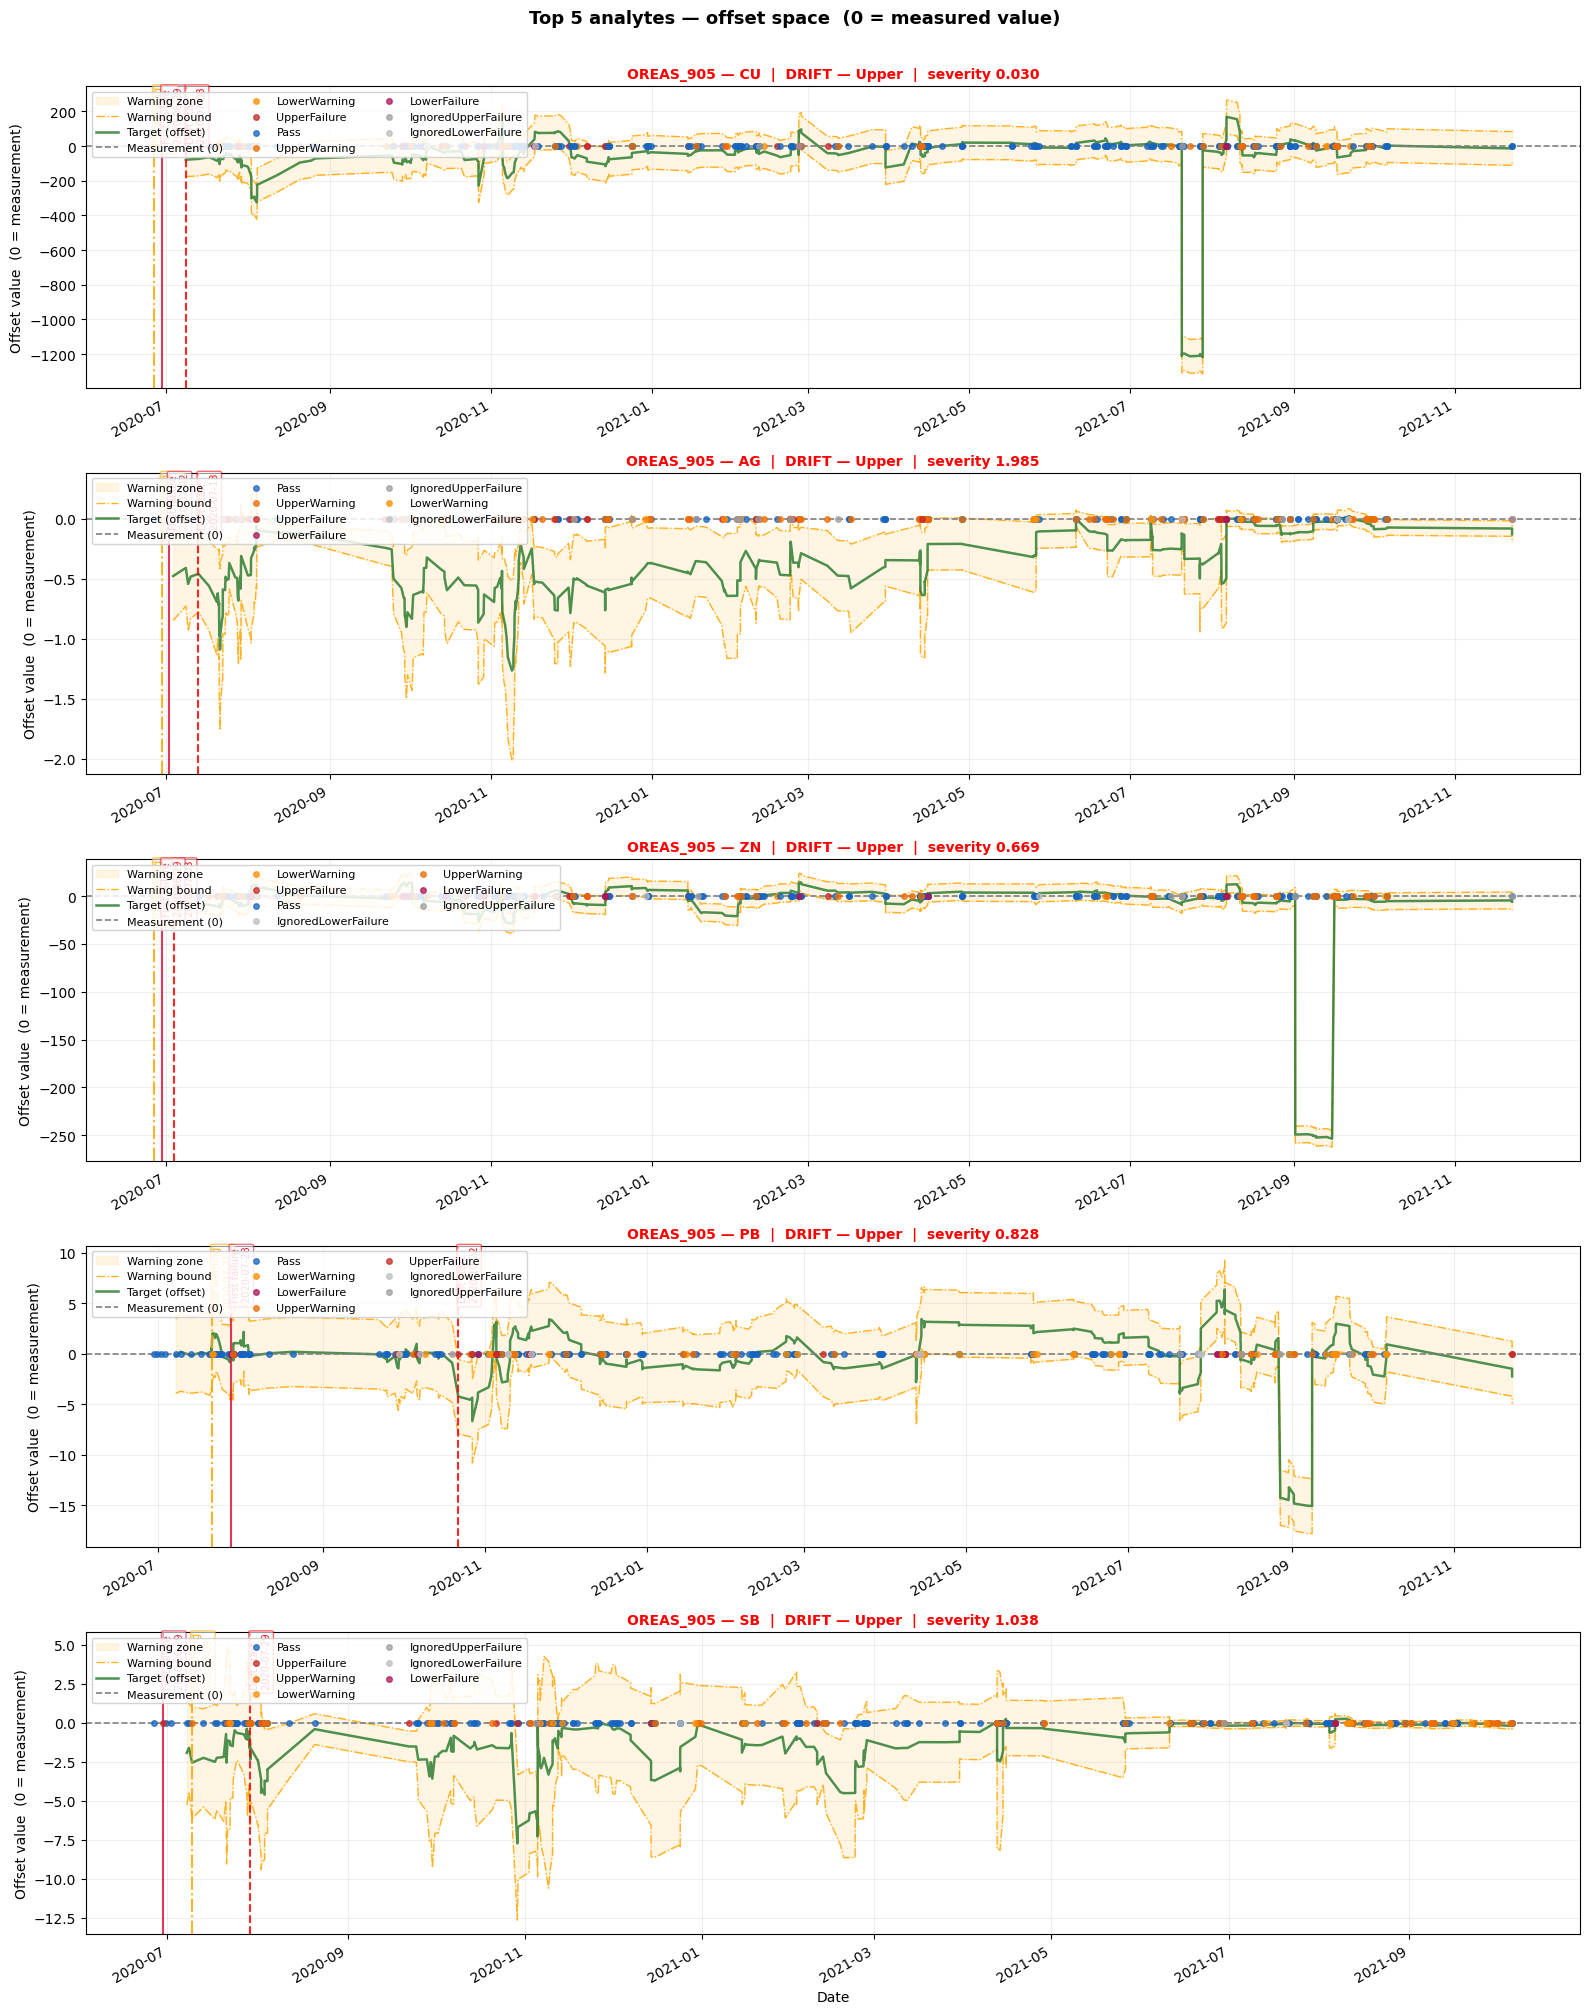

In [6]:
TOP_N = 5  # number of most-common analytes to show

top_analytes = (
    pd.Series({a: len(adf) for a, adf in analyte_data.items()})
    .sort_values(ascending=False)
    .head(TOP_N)
    .index.tolist()
)

fig, axes = plt.subplots(TOP_N, 1, figsize=(16, 4 * TOP_N), sharex=False)
if TOP_N == 1:
    axes = [axes]

for ax, analyte in zip(axes, top_analytes):
    adf   = analyte_data[analyte]
    dates = adf["ANALYSED_DATE"]

    win = min(ROLLING_WINDOW, len(adf))
    roll_kw = dict(window=win, min_periods=max(1, win // 2))
    roll_offset_target = adf["OFFSET_TARGET"].rolling(**roll_kw).mean()
    roll_offset_max    = adf["OFFSET_MAX_WARN"].rolling(**roll_kw).mean()
    roll_offset_min    = adf["OFFSET_MIN_WARN"].rolling(**roll_kw).mean()

    ax.fill_between(dates, roll_offset_min, roll_offset_max,
                    color="#ffe0a0", alpha=0.30, label="Warning zone")
    ax.plot(dates, roll_offset_max, color="orange", linestyle="-.", linewidth=1.0, alpha=0.85)
    ax.plot(dates, roll_offset_min, color="orange", linestyle="-.", linewidth=1.0, alpha=0.85,
            label="Warning bound")
    ax.plot(dates, roll_offset_target, color="#2E7D32", linewidth=1.8, alpha=0.85,
            label="Target (offset)")
    ax.axhline(0, color="grey", linestyle="--", linewidth=1.2, label="Measurement (0)")

    # Points coloured by STANDARD_STATUS
    if "STANDARD_STATUS" in adf.columns:
        plot_df = adf.copy()
        plot_df["STANDARD_STATUS"] = plot_df["STANDARD_STATUS"].fillna("Pass").astype(str)
        for status in plot_df["STANDARD_STATUS"].unique():
            grp   = plot_df[plot_df["STANDARD_STATUS"] == status]
            color = STATUS_COLORS.get(status, "#607D8B")
            ax.scatter(grp["ANALYSED_DATE"], grp["OFFSET_VALUE"],
                       s=16, color=color, alpha=0.75, zorder=3, label=status)

    # Drift / warning / failure markers
    info = summary[summary["ANALYTE_CODE"] == analyte].iloc[0]
    for dt, color, ls, lbl in [
        (info["drift_start"],        "red",    "--", "Drift start"),
        (info["first_warning_date"], "orange", "-.", "First warning"),
        (info["first_failure_date"], "crimson", "-", "First failure"),
    ]:
        if pd.notna(dt):
            ax.axvline(dt, color=color, linestyle=ls, linewidth=1.5, alpha=0.85)
            ax.text(dt, ax.get_ylim()[1], f" {lbl}\n {_fmt_date(dt)}",
                    color=color, fontsize=7, va="top", rotation=90,
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.6, ec=color))

    ax.set_ylabel("Offset value  (0 = measurement)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
    ax.grid(alpha=0.2)

    drift_label = (
        f"DRIFT — {info['drift_direction']}  |  severity {info['severity_score']:.3f}"
        if info["drift_detected"] else f"No drift  |  severity {info['severity_score']:.3f}"
    )
    ax.set_title(f"{STD_LOT_CODE} — {analyte}  |  {drift_label}",
                 fontsize=10, fontweight="bold",
                 color="red" if info["drift_detected"] else "#2E7D32")
    ax.legend(fontsize=8, ncol=3, loc="upper left", framealpha=0.85)

axes[-1].set_xlabel("Date")
fig.suptitle(f"Top {TOP_N} analytes — offset space  (0 = measured value)",
             fontsize=13, fontweight="bold", y=1.005)
plt.tight_layout()
plt.show()

### Single-analyte filter\nSet `analyte_filter` to any analyte code from the summary table above, then run the next cell.

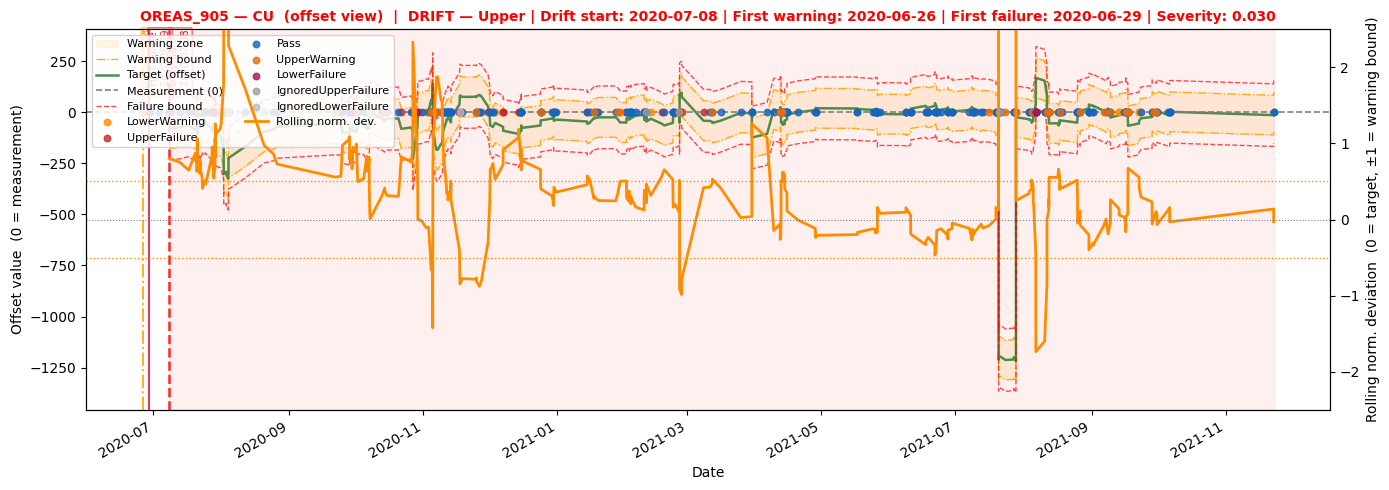

In [7]:
analyte_filter = "CU"   # ← change to any ANALYTE_CODE from the summary table above

if analyte_filter not in analyte_data:
    print(f"'{analyte_filter}' not found. Available analytes:")
    print(sorted(analyte_data.keys()))
else:
    adf        = analyte_data[analyte_filter]
    drift_info = summary[summary["ANALYTE_CODE"] == analyte_filter].iloc[0].to_dict()

    dates = adf["ANALYSED_DATE"]
    win   = min(ROLLING_WINDOW, len(adf))
    roll_kw = dict(window=win, min_periods=max(1, win // 2))

    roll_offset_target = adf["OFFSET_TARGET"].rolling(**roll_kw).mean()
    roll_offset_max    = adf["OFFSET_MAX_WARN"].rolling(**roll_kw).mean()
    roll_offset_min    = adf["OFFSET_MIN_WARN"].rolling(**roll_kw).mean()

    fig, ax1 = plt.subplots(figsize=(14, 5))

    ax1.fill_between(dates, roll_offset_min, roll_offset_max,
                     color="#ffe0a0", alpha=0.30, label="Warning zone")
    ax1.plot(dates, roll_offset_max, color="orange", linestyle="-.", linewidth=1.0,
             alpha=0.9, label="Warning bound")
    ax1.plot(dates, roll_offset_min, color="orange", linestyle="-.", linewidth=1.0, alpha=0.9)
    ax1.plot(dates, roll_offset_target, color="#2E7D32", linewidth=1.8,
             alpha=0.85, label="Target (offset)")
    ax1.axhline(0, color="grey", linestyle="--", linewidth=1.2, label="Measurement (0)")

    if "OFFSET_MAX_FAIL" in adf.columns:
        ax1.plot(dates, adf["OFFSET_MAX_FAIL"].rolling(**roll_kw).mean(),
                 color="red", linestyle="--", linewidth=1.0, alpha=0.7, label="Failure bound")
        ax1.plot(dates, adf["OFFSET_MIN_FAIL"].rolling(**roll_kw).mean(),
                 color="red", linestyle="--", linewidth=1.0, alpha=0.7)

    if "STANDARD_STATUS" in adf.columns:
        plot_df = adf.copy()
        plot_df["STANDARD_STATUS"] = plot_df["STANDARD_STATUS"].fillna("Pass").astype(str)
        for status in plot_df["STANDARD_STATUS"].unique():
            grp   = plot_df[plot_df["STANDARD_STATUS"] == status]
            color = STATUS_COLORS.get(status, "#607D8B")
            ax1.scatter(grp["ANALYSED_DATE"], grp["OFFSET_VALUE"],
                        s=22, color=color, alpha=0.8, zorder=3, label=status)
    else:
        ax1.scatter(dates, adf["OFFSET_VALUE"], s=22, color="#1565C0",
                    alpha=0.8, zorder=3, label="Pass")

    ax2 = ax1.twinx()
    ax2.plot(dates, adf["rolling_norm_dev"], color="darkorange", linewidth=2.0, zorder=2)
    ax2.axhline( DRIFT_THRESHOLD, color="darkorange", linestyle=":", linewidth=1.0)
    ax2.axhline(-DRIFT_THRESHOLD, color="darkorange", linestyle=":", linewidth=1.0)
    ax2.axhline(0, color="grey", linestyle=":", linewidth=0.8)
    ax2.set_ylabel("Rolling norm. deviation  (0 = target, ±1 = warning bound)")
    ax2.set_ylim(-2.5, 2.5)

    ymax = ax1.get_ylim()[1]
    for dt, color, ls, lw, lbl in [
        (drift_info.get("drift_start"),        "red",     "--", 1.8, "Drift start"),
        (drift_info.get("first_warning_date"),  "orange",  "-.", 1.5, "First warning"),
        (drift_info.get("first_failure_date"),  "crimson", "-",  1.5, "First failure"),
    ]:
        if pd.notna(dt):
            ax1.axvline(dt, color=color, linestyle=ls, linewidth=lw, alpha=0.85, zorder=4)
            ax1.text(dt, ymax, f" {lbl}\n {_fmt_date(dt)}",
                     color=color, fontsize=7, va="top", rotation=90,
                     bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.6, ec=color))

    if drift_info.get("drift_detected") and pd.notna(drift_info.get("drift_start")):
        ax1.axvspan(drift_info["drift_start"], dates.iloc[-1], color="red", alpha=0.06)

    handles1, labels1 = ax1.get_legend_handles_labels()
    rolling_handle = Line2D([0], [0], color="darkorange", linewidth=2, label="Rolling norm. dev.")
    ax1.legend(handles1 + [rolling_handle], labels1 + ["Rolling norm. dev."],
               loc="upper left", fontsize=8, framealpha=0.85, ncol=2)

    ax1.set_xlabel("Date")
    ax1.set_ylabel("Offset value  (0 = measurement)")
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha="right")

    status_text = (
        f"DRIFT — {drift_info['drift_direction']} | "
        f"Drift start: {_fmt_date(drift_info.get('drift_start'))} | "
        f"First warning: {_fmt_date(drift_info.get('first_warning_date'))} | "
        f"First failure: {_fmt_date(drift_info.get('first_failure_date'))} | "
        f"Severity: {drift_info['severity_score']:.3f}"
        if drift_info.get("drift_detected")
        else (
            f"No drift | "
            f"First warning: {_fmt_date(drift_info.get('first_warning_date'))} | "
            f"First failure: {_fmt_date(drift_info.get('first_failure_date'))} | "
            f"Severity: {drift_info['severity_score']:.3f}"
        )
    )
    ax1.set_title(
        f"{STD_LOT_CODE} — {analyte_filter}  (offset view)  |  {status_text}",
        fontsize=10, fontweight="bold",
        color="red" if drift_info.get("drift_detected") else "#2E7D32"
    )
    plt.tight_layout()
    plt.show()

## 6. Per-Analyte Offset Plots

Each plot shows the analyte in **offset space**:  
- **Measurement** is always at 0 (blue scatter dots, all on the x-axis).  
- **Offset target** (green line) and **offset warning bounds** (orange lines) move relative to the measurement.  
- When the warning bounds converge toward 0, the measurement is approaching the warning limit.  
- The right axis shows the rolling normalised deviation (unchanged from base notebook).

In [8]:
def plot_analyte_offset(adf: pd.DataFrame,
                        analyte: str,
                        std_lot_code: str,
                        drift_info: dict,
                        drift_threshold: float = 0.5) -> None:
    """Per-analyte offset-space time-series plot."""
    fig, ax1 = plt.subplots(figsize=(14, 5))

    dates = adf["ANALYSED_DATE"]

    # ── Offset reference lines (rolling mean to smooth per-row variance) ──────
    win = min(ROLLING_WINDOW, len(adf))
    min_periods = max(1, win // 2)

    roll_kw = dict(window=win, min_periods=min_periods)
    r_target   = adf["OFFSET_TARGET"].rolling(**roll_kw).mean()
    r_max_warn = adf["OFFSET_MAX_WARN"].rolling(**roll_kw).mean()
    r_min_warn = adf["OFFSET_MIN_WARN"].rolling(**roll_kw).mean()

    # Warning band between rolling offset bounds
    ax1.fill_between(dates, r_min_warn, r_max_warn,
                     color="#ffe0a0", alpha=0.25, label="Warning zone (offset)")

    # Offset failure bounds (if available)
    for col, lbl in [("OFFSET_MAX_FAIL", "Failure bound (offset)"),
                     ("OFFSET_MIN_FAIL", None)]:
        if col in adf.columns:
            r = adf[col].rolling(**roll_kw).mean()
            ax1.plot(dates, r, color="red", linestyle="--", linewidth=1.0, alpha=0.7,
                     label=lbl if lbl else "_nolegend_")

    # Offset warning bounds
    ax1.plot(dates, r_max_warn, color="orange", linestyle="-.", linewidth=1.0,
             alpha=0.9, label="Warning bound (offset)")
    ax1.plot(dates, r_min_warn, color="orange", linestyle="-.", linewidth=1.0,
             alpha=0.9)

    # Offset target
    ax1.plot(dates, r_target, color="#2E7D32", linestyle="-", linewidth=1.8,
             alpha=0.85, label="Target (offset)")

    # Measurement = 0 reference
    ax1.axhline(0, color="grey", linestyle="--", linewidth=1.0, alpha=0.7,
                label="Measurement (0)")

    # ── Scatter: measurement points at 0, coloured by STANDARD_STATUS ────────
    if "STANDARD_STATUS" in adf.columns:
        plot_df = adf.copy()
        plot_df["STANDARD_STATUS"] = plot_df["STANDARD_STATUS"].fillna("Pass").astype(str)
        for status in plot_df["STANDARD_STATUS"].unique():
            grp = plot_df[plot_df["STANDARD_STATUS"] == status]
            color = STATUS_COLORS.get(status, "#607D8B")
            ax1.scatter(grp["ANALYSED_DATE"], grp["OFFSET_VALUE"],
                        s=22, color=color, alpha=0.8, zorder=3, label=status)
    else:
        ax1.scatter(dates, adf["OFFSET_VALUE"],
                    s=22, color="#1565C0", alpha=0.8, zorder=3, label="Pass")

    ax1.set_xlabel("Date")
    ax1.set_ylabel("Offset value  (0 = measurement)")
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha="right")

    # ── Right axis: rolling normalised deviation ──────────────────────────────
    ax2 = ax1.twinx()
    ax2.plot(dates, adf["rolling_norm_dev"],
             color="darkorange", linewidth=2.0, zorder=2)
    ax2.axhline( drift_threshold, color="darkorange", linestyle=":", linewidth=1.0)
    ax2.axhline(-drift_threshold, color="darkorange", linestyle=":", linewidth=1.0)
    ax2.axhline(0, color="grey", linestyle=":", linewidth=0.8)
    ax2.set_ylabel("Rolling norm. deviation  (0 = target, ±1 = warning bound)")
    ax2.set_ylim(-2.5, 2.5)

    # ── Vertical markers: drift start, first warning, first failure ───────────
    vlines = [
        (drift_info.get("drift_start"),        "red",    "--", 1.8, "Drift start"),
        (drift_info.get("first_warning_date"),  "orange", "-.", 1.5, "First warning"),
        (drift_info.get("first_failure_date"),  "crimson","-",  1.5, "First failure"),
    ]
    ymax = ax1.get_ylim()[1]

    for dt, color, ls, lw, label in vlines:
        if pd.notna(dt):
            ax1.axvline(dt, color=color, linestyle=ls, linewidth=lw, alpha=0.85, zorder=4)
            ax1.text(dt, ymax, f" {label}\n {_fmt_date(dt)}",
                     color=color, fontsize=7, va="top", rotation=90,
                     bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.6, ec=color))

    if drift_info.get("drift_detected") and pd.notna(drift_info.get("drift_start")):
        ax1.axvspan(drift_info["drift_start"], dates.iloc[-1],
                    color="red", alpha=0.06)

    # ── Legend ────────────────────────────────────────────────────────────────
    handles1, labels1 = ax1.get_legend_handles_labels()
    rolling_handle = Line2D([0], [0], color="darkorange", linewidth=2,
                            label="Rolling norm. dev.")
    ax1.legend(handles1 + [rolling_handle], labels1 + ["Rolling norm. dev."],
               loc="upper left", fontsize=8, framealpha=0.85, ncol=2)

    status_text = (
        f"DRIFT — {drift_info['drift_direction']} | "
        f"Drift start: {_fmt_date(drift_info.get('drift_start'))} | "
        f"First warning: {_fmt_date(drift_info.get('first_warning_date'))} | "
        f"First failure: {_fmt_date(drift_info.get('first_failure_date'))} | "
        f"Severity: {drift_info['severity_score']:.3f}"
        if drift_info.get("drift_detected")
        else (
            f"No drift | "
            f"First warning: {_fmt_date(drift_info.get('first_warning_date'))} | "
            f"First failure: {_fmt_date(drift_info.get('first_failure_date'))} | "
            f"Severity: {drift_info['severity_score']:.3f}"
        )
    )
    title_color = "red" if drift_info.get("drift_detected") else "#2E7D32"
    ax1.set_title(
        f"{std_lot_code} — {analyte}  (offset view)  |  {status_text}",
        fontsize=10, color=title_color, fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

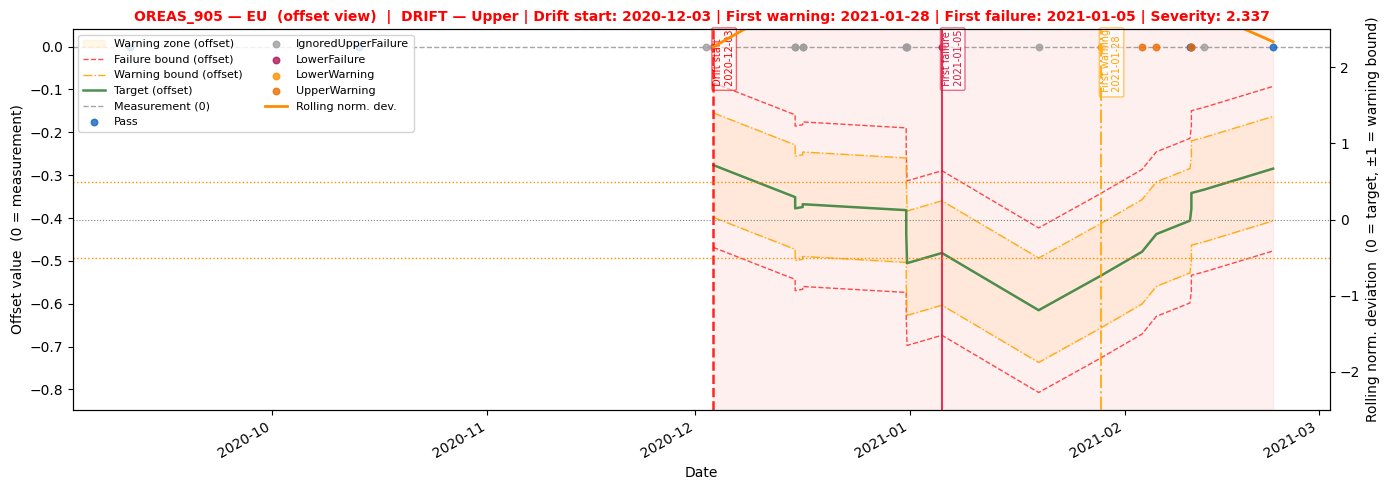

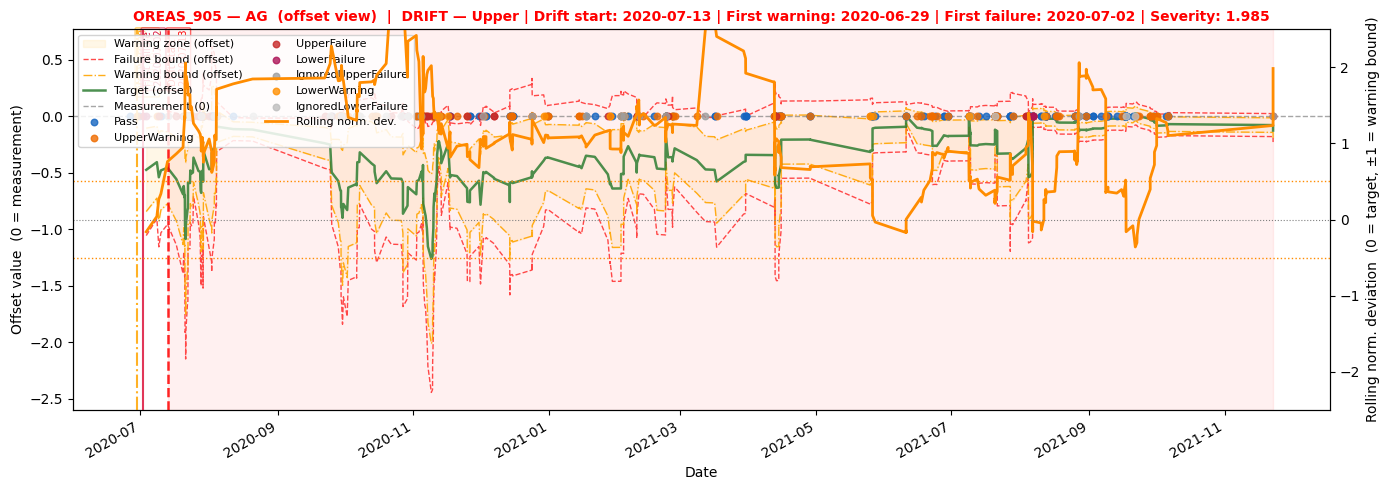

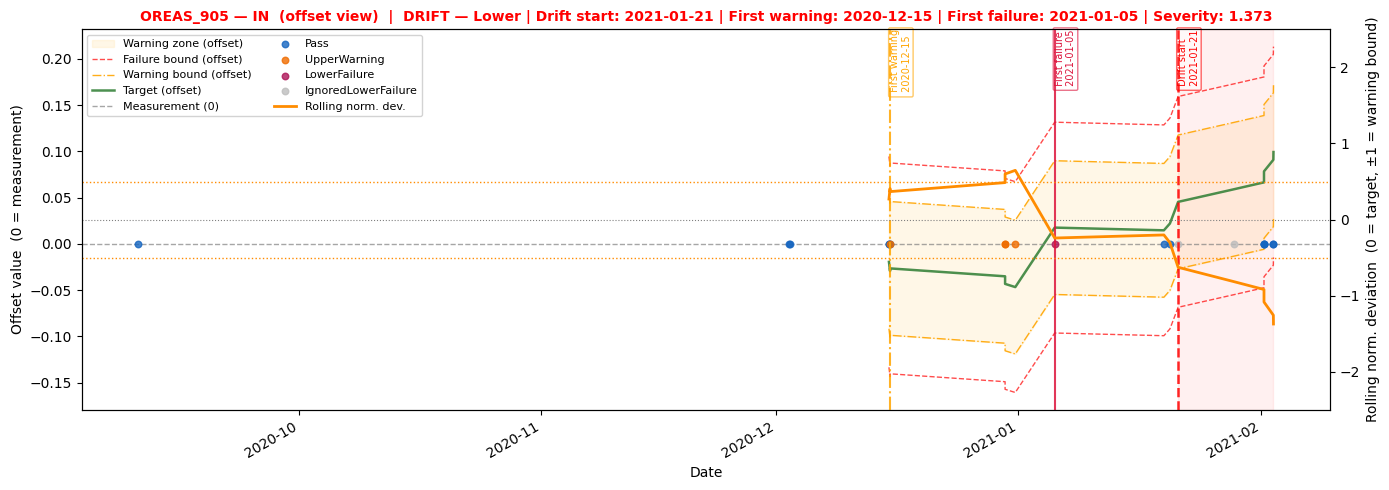

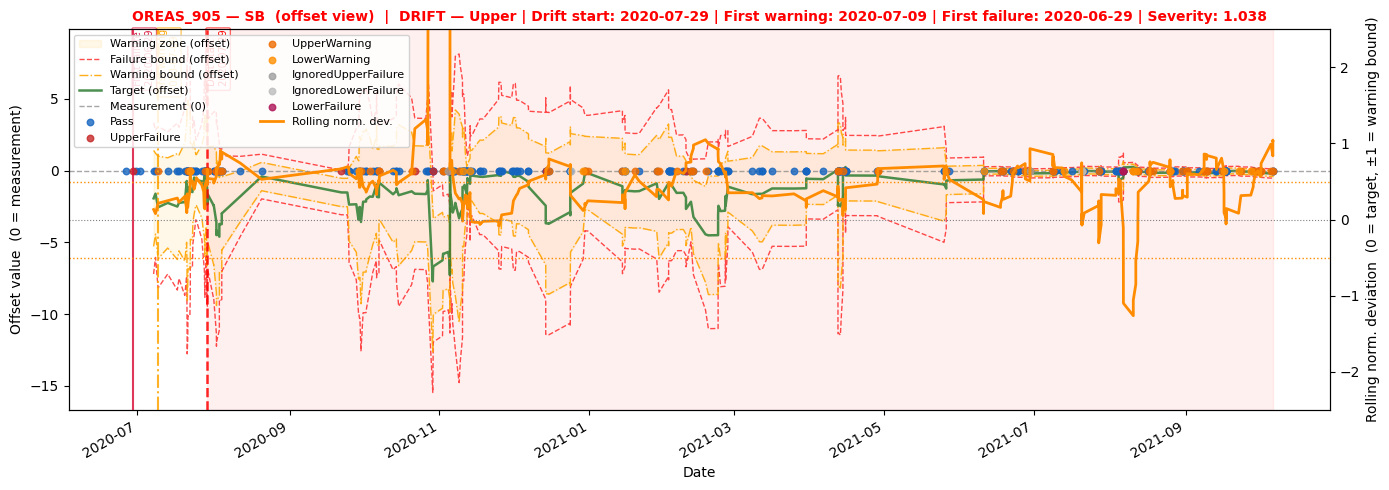

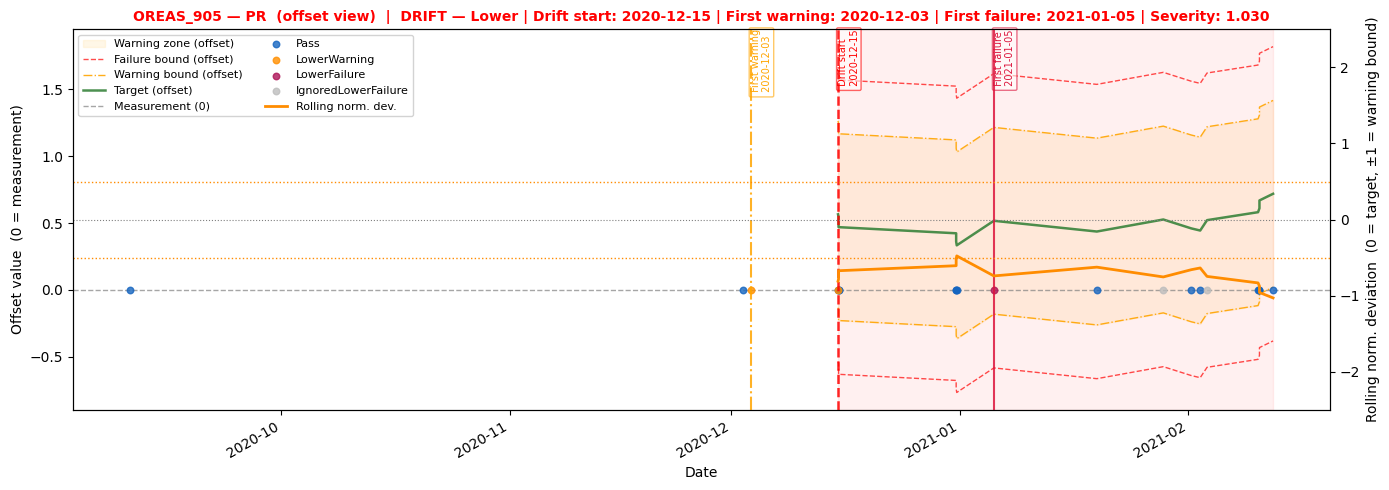

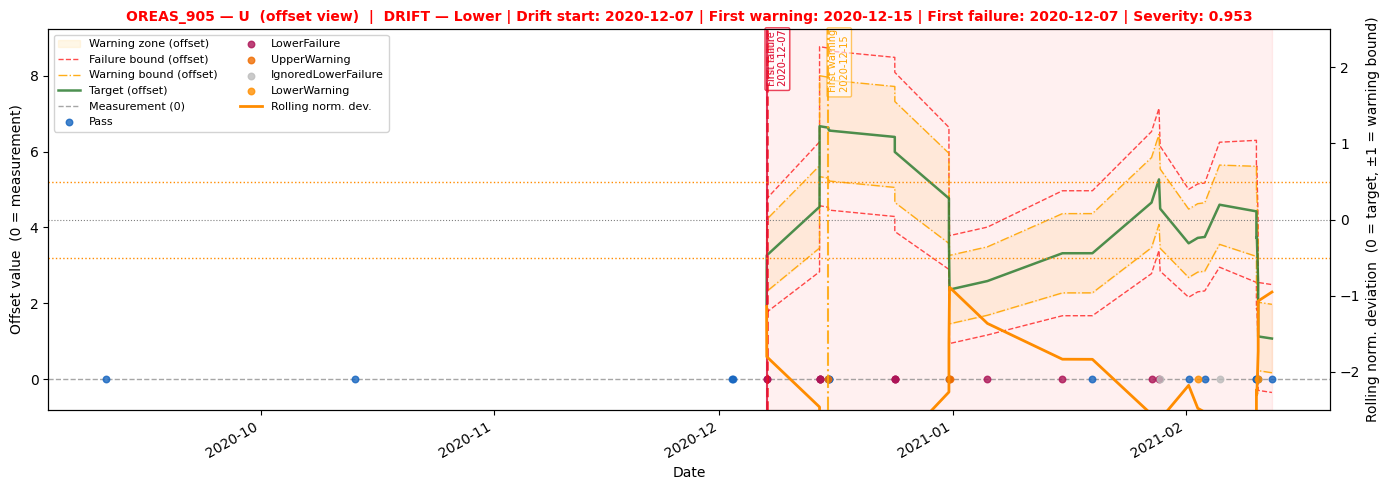

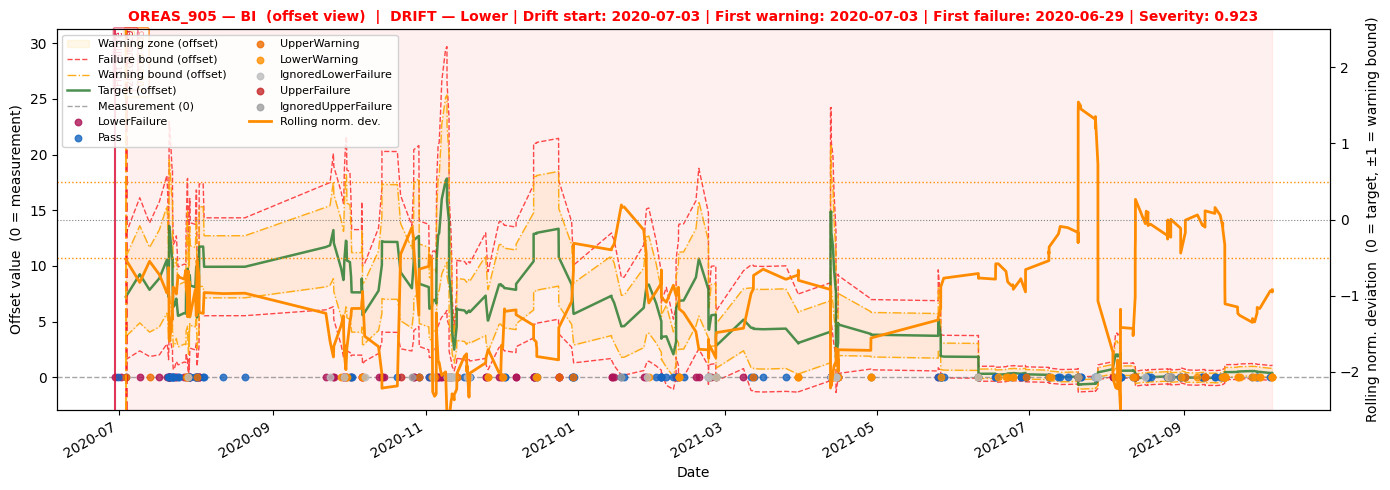

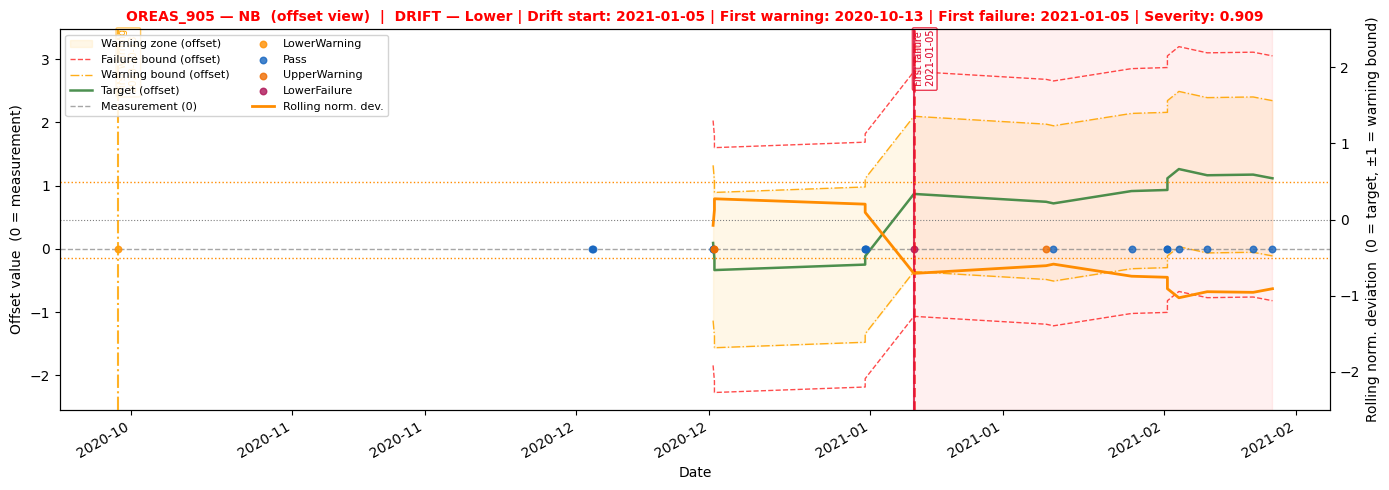

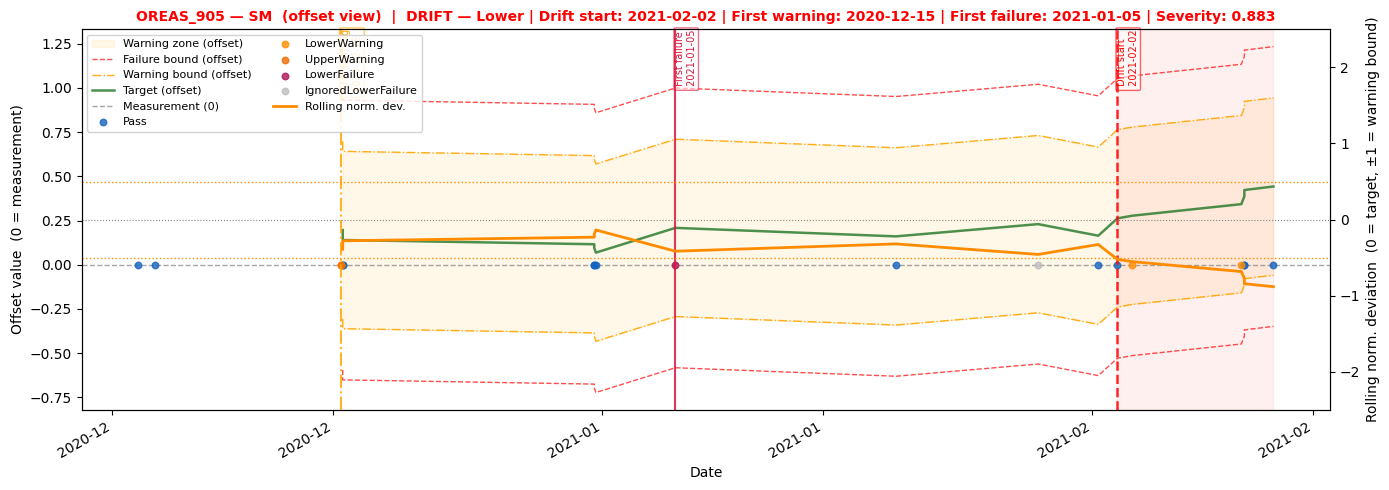

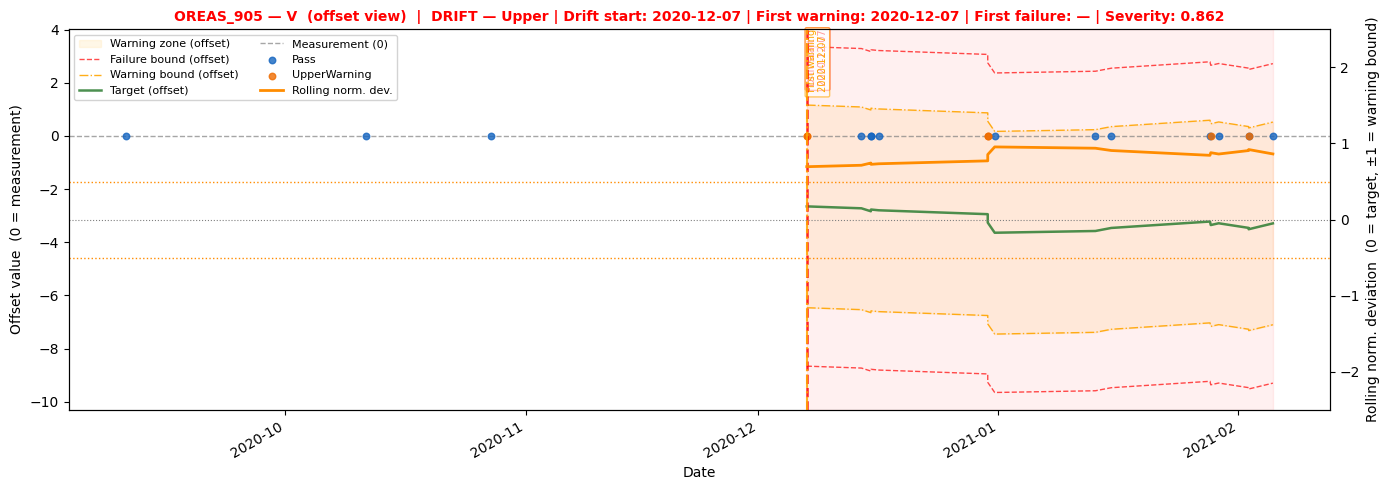

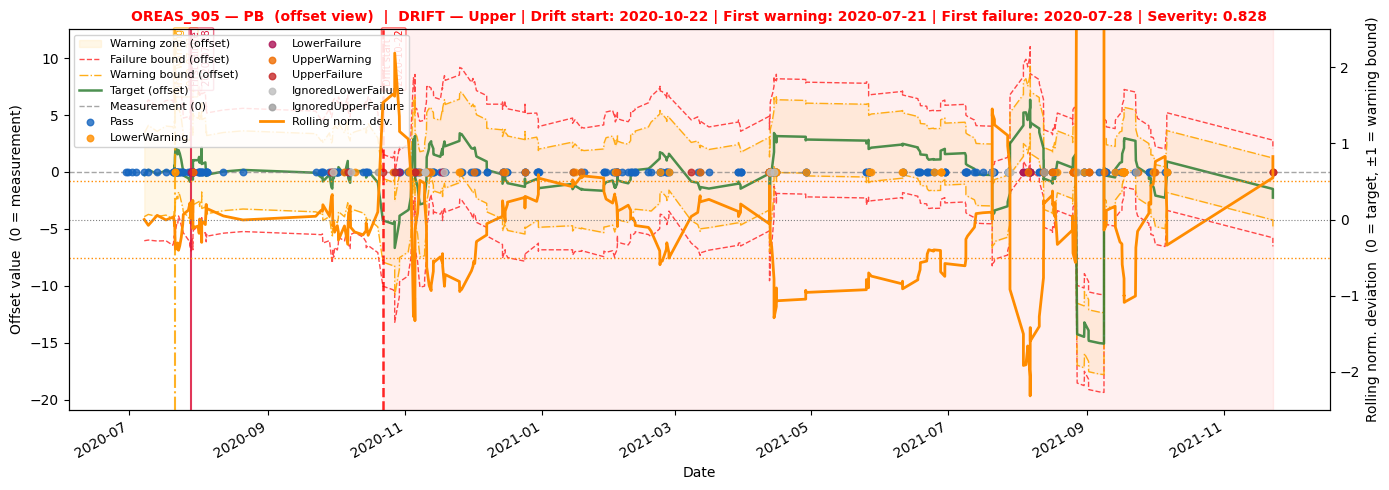

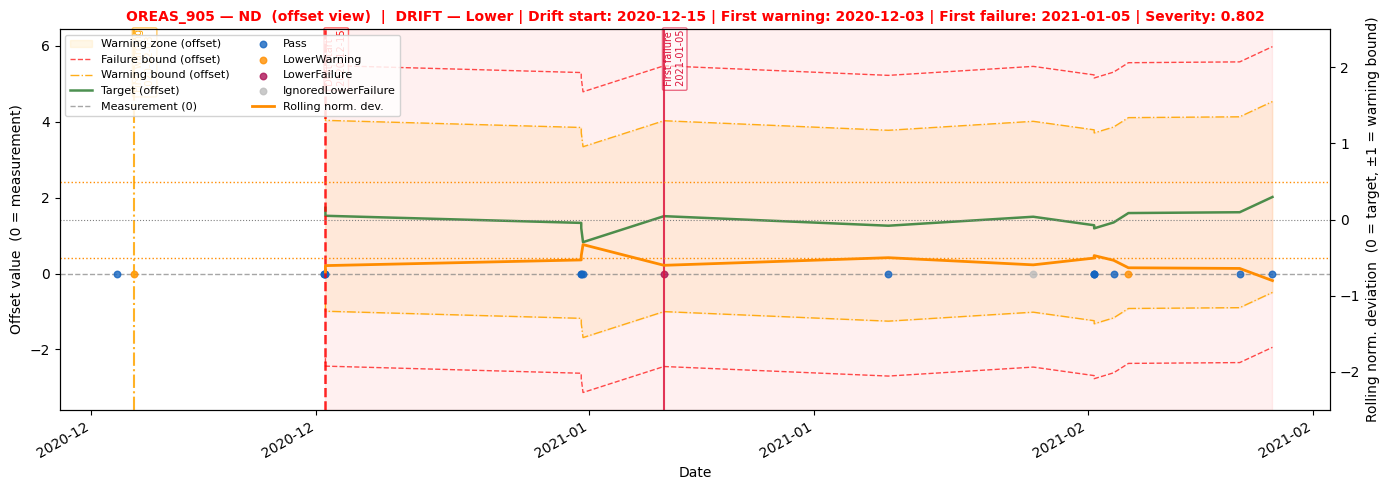

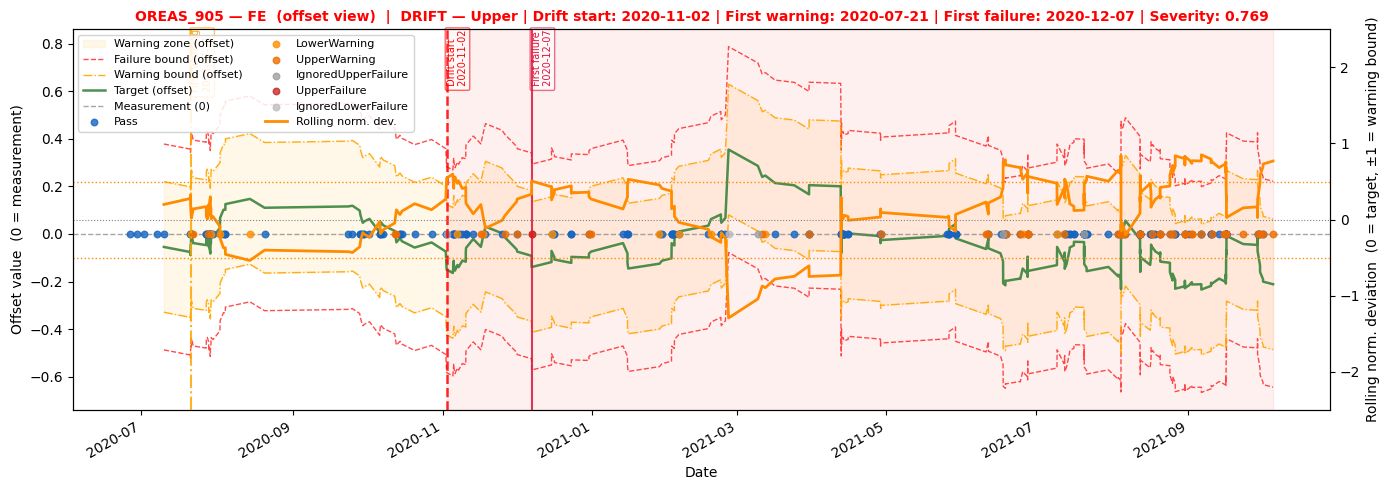

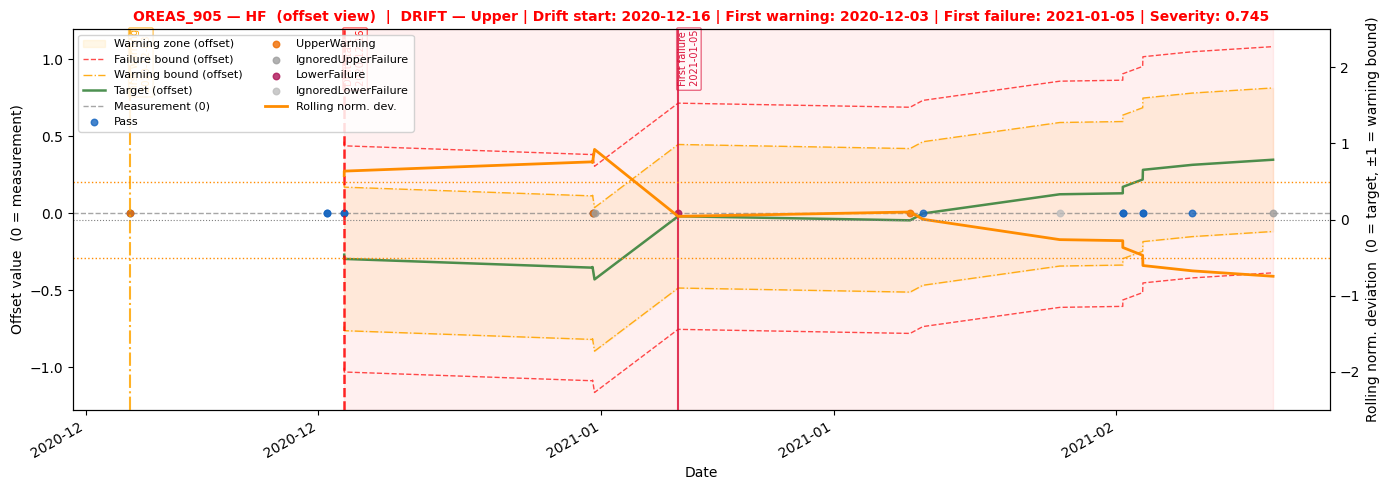

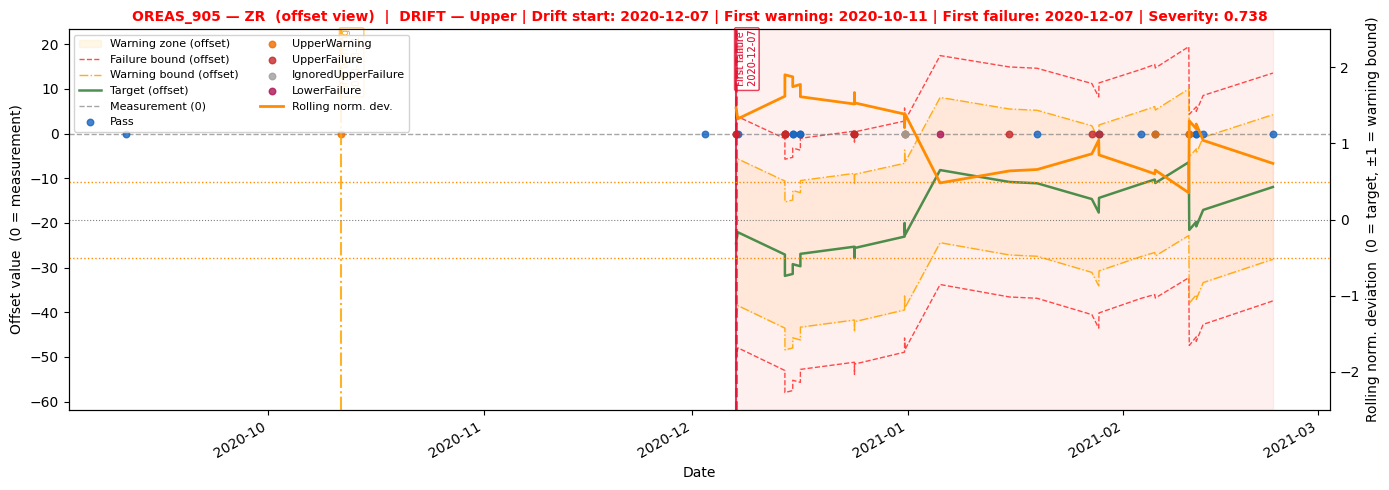

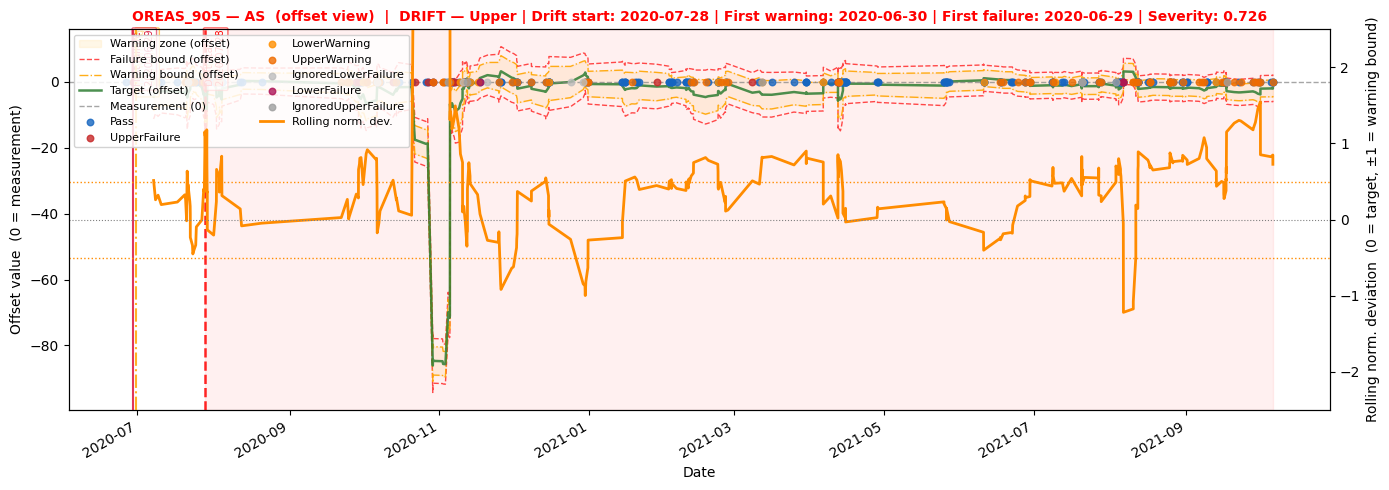

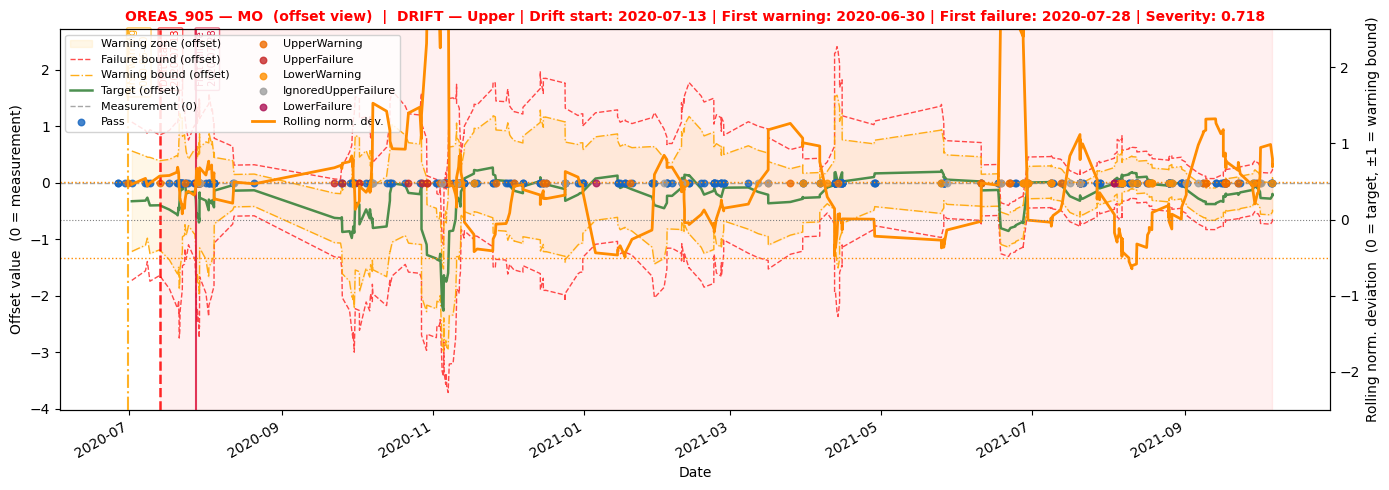

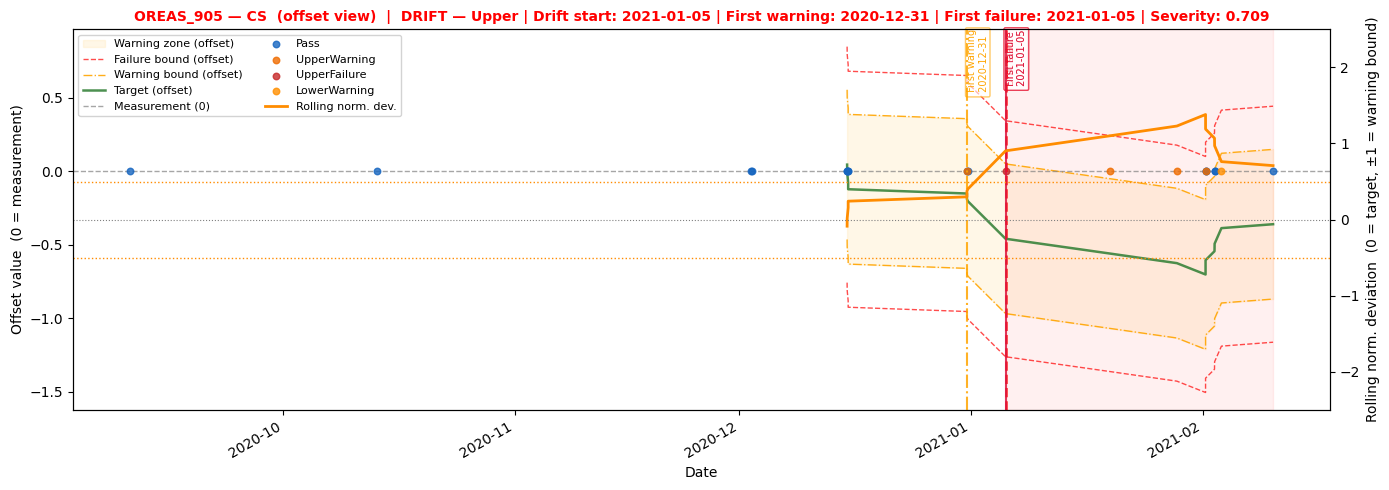

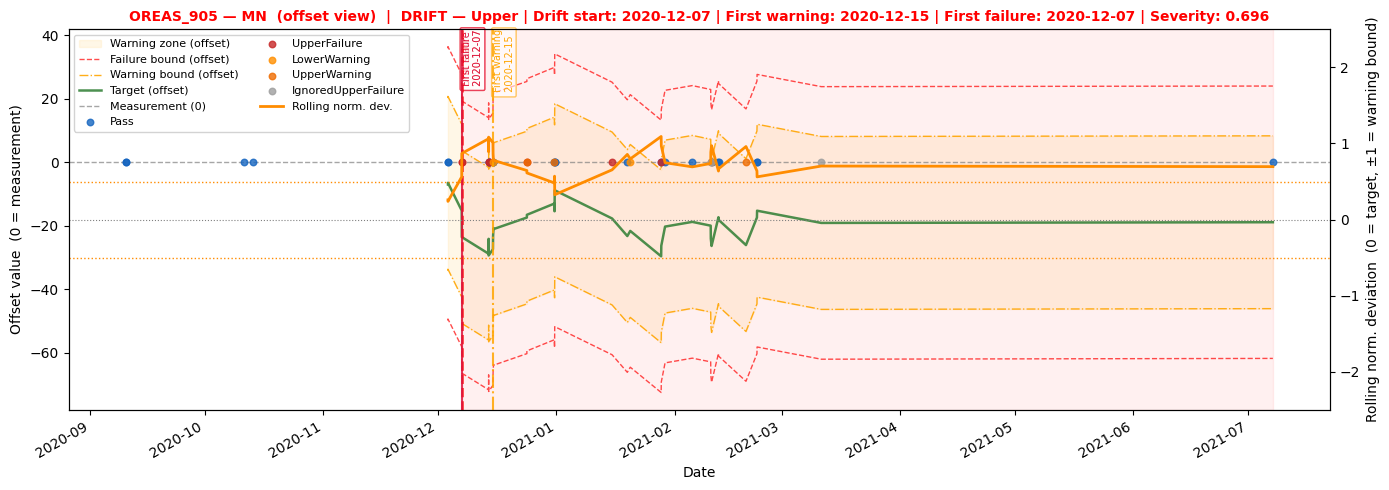

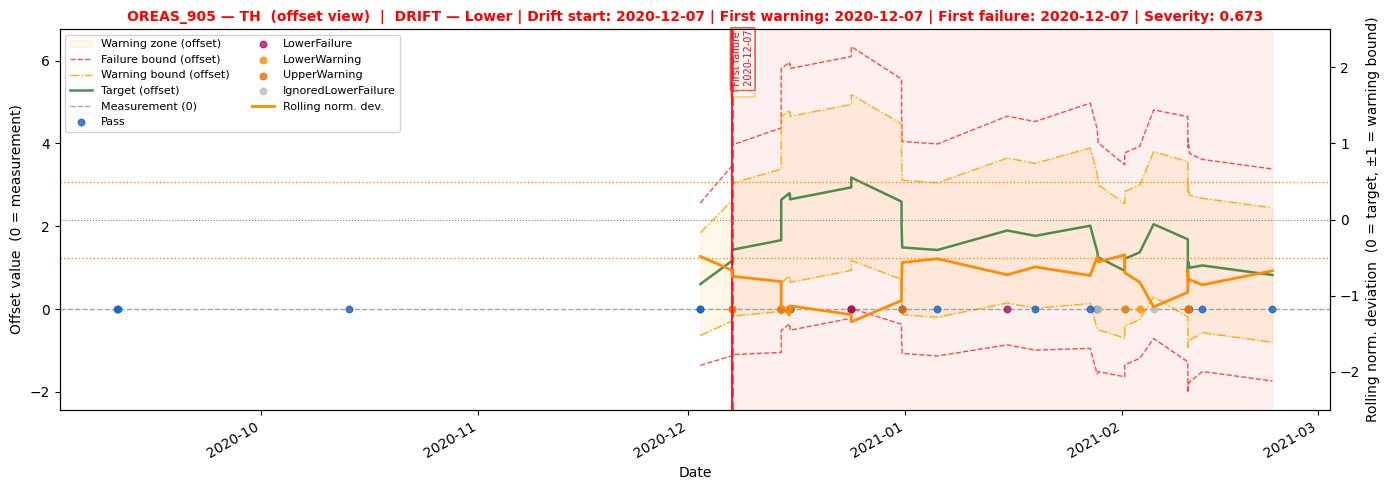

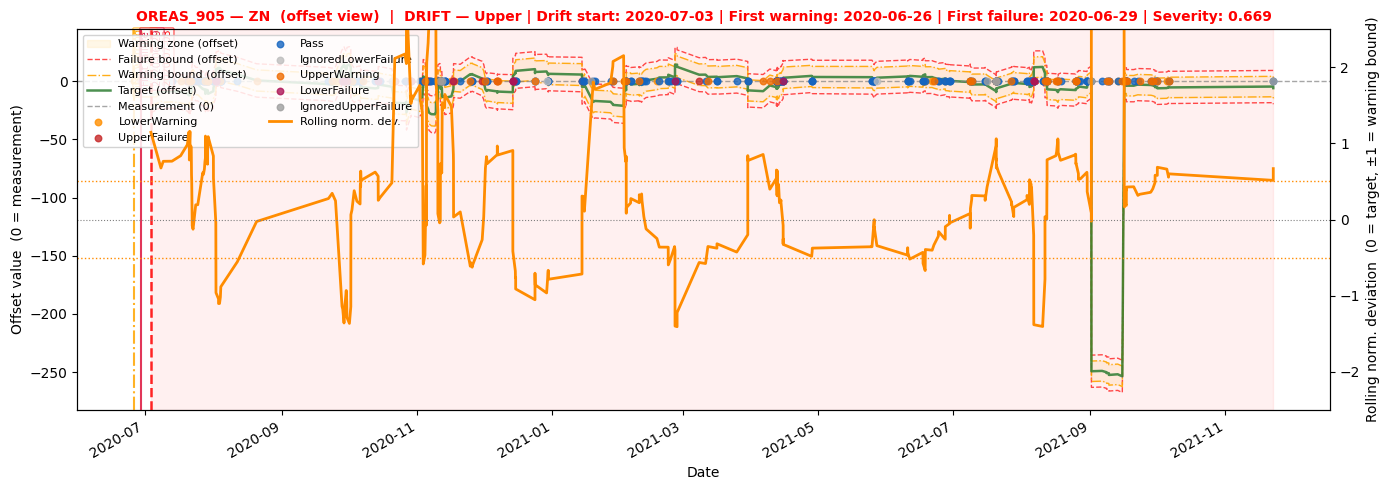

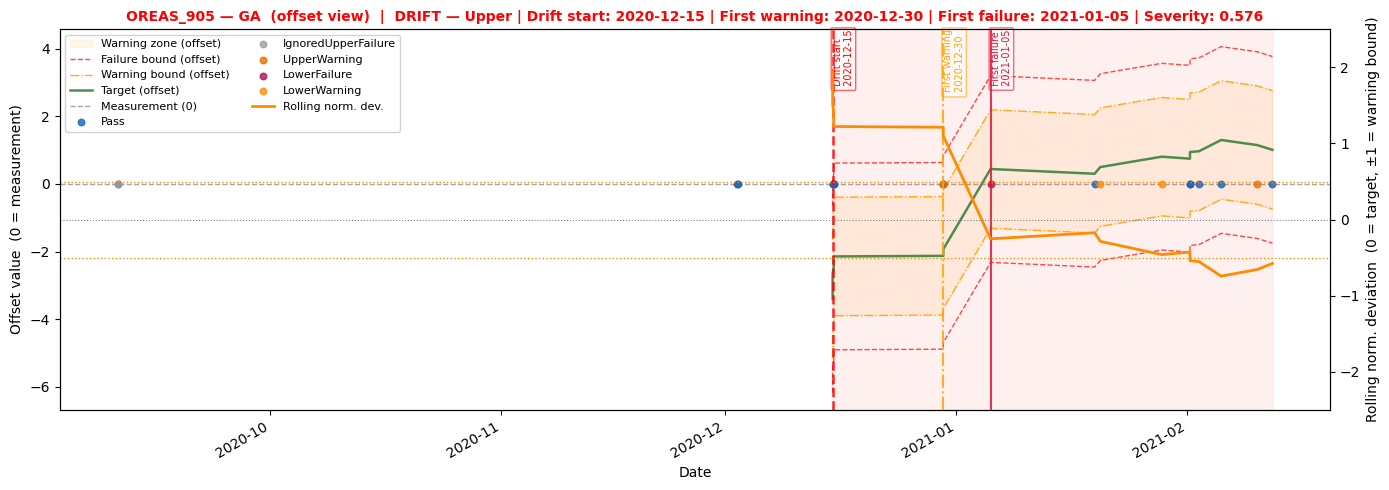

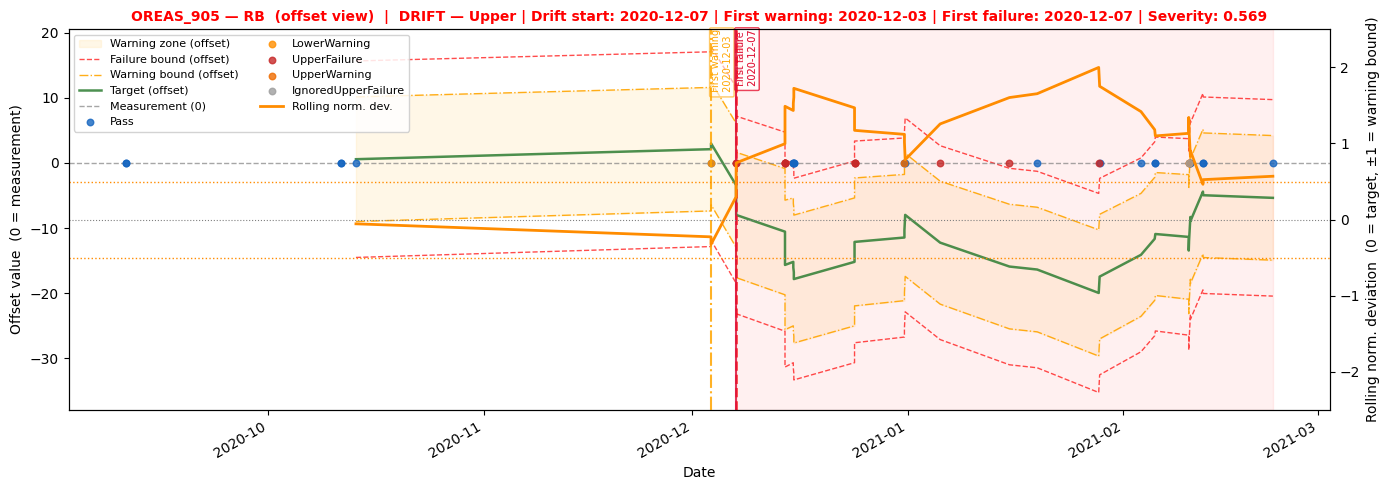

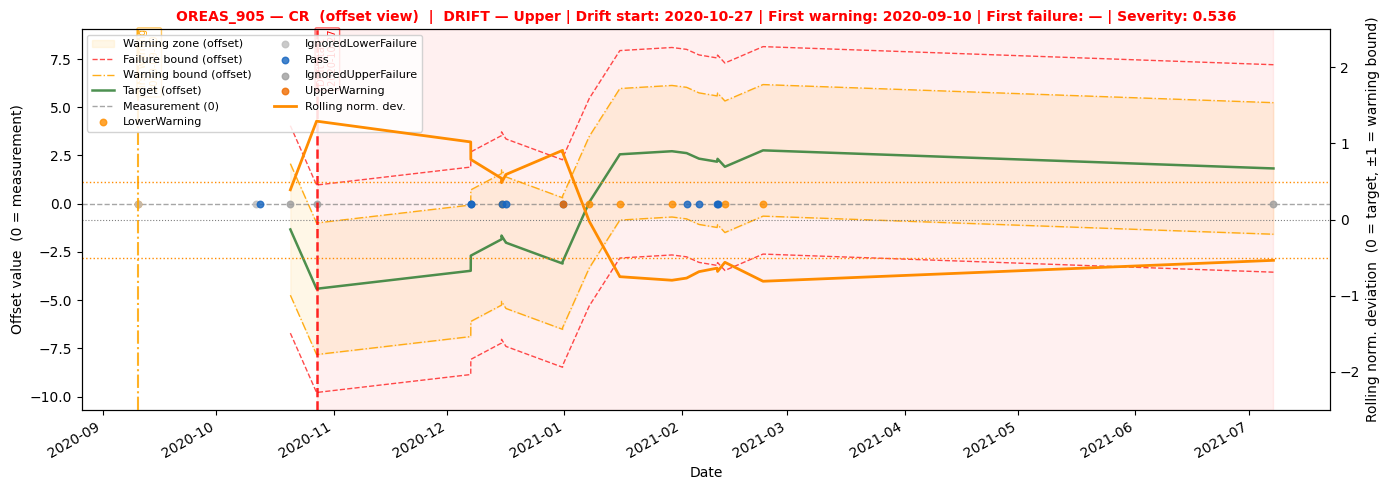

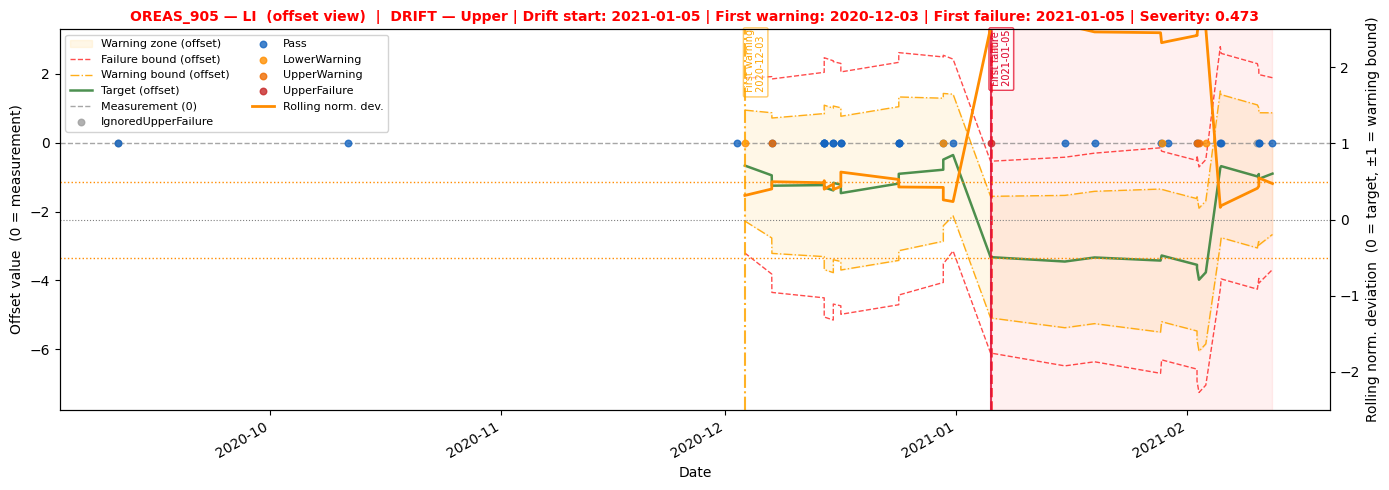

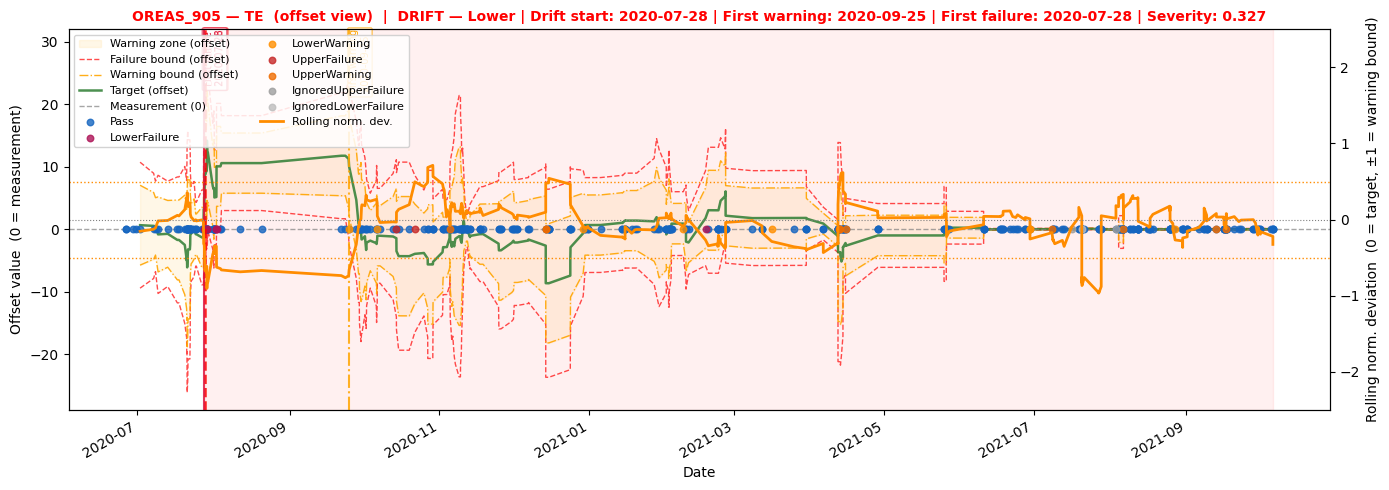

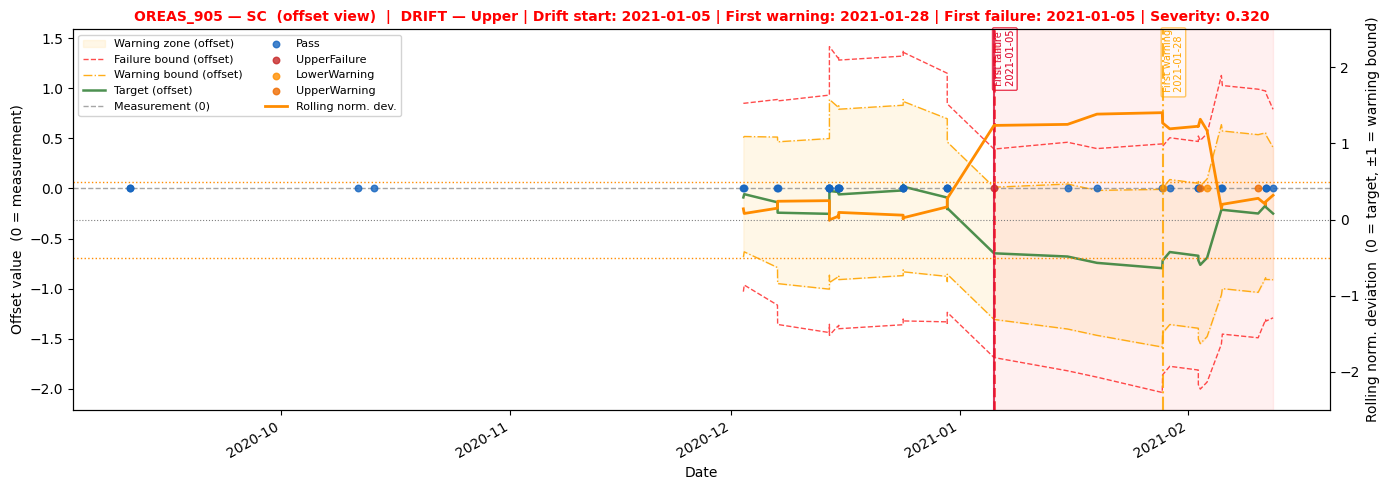

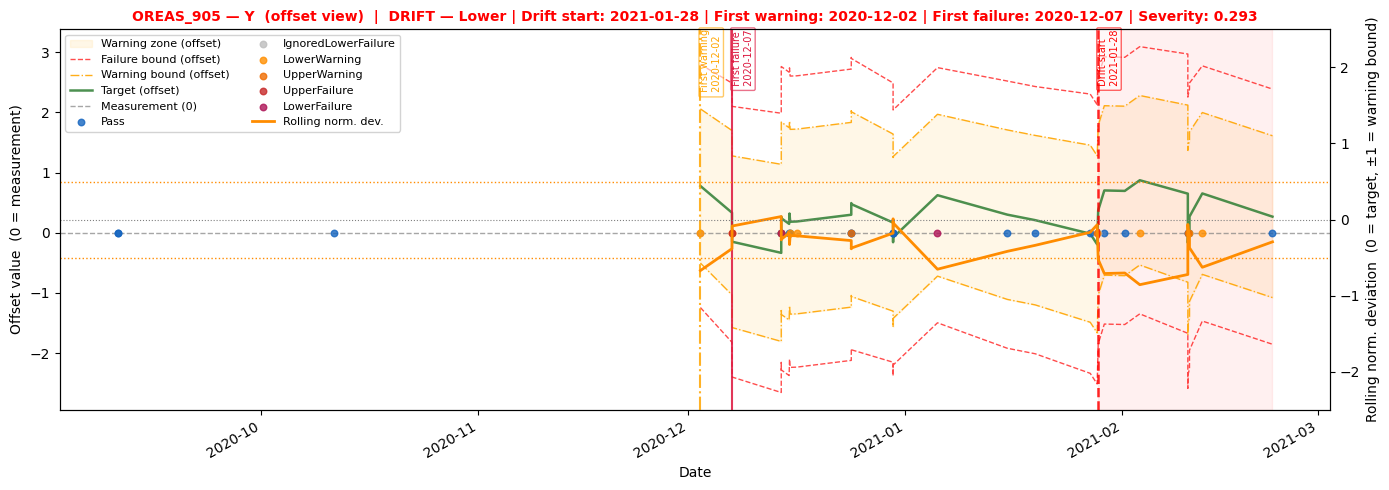

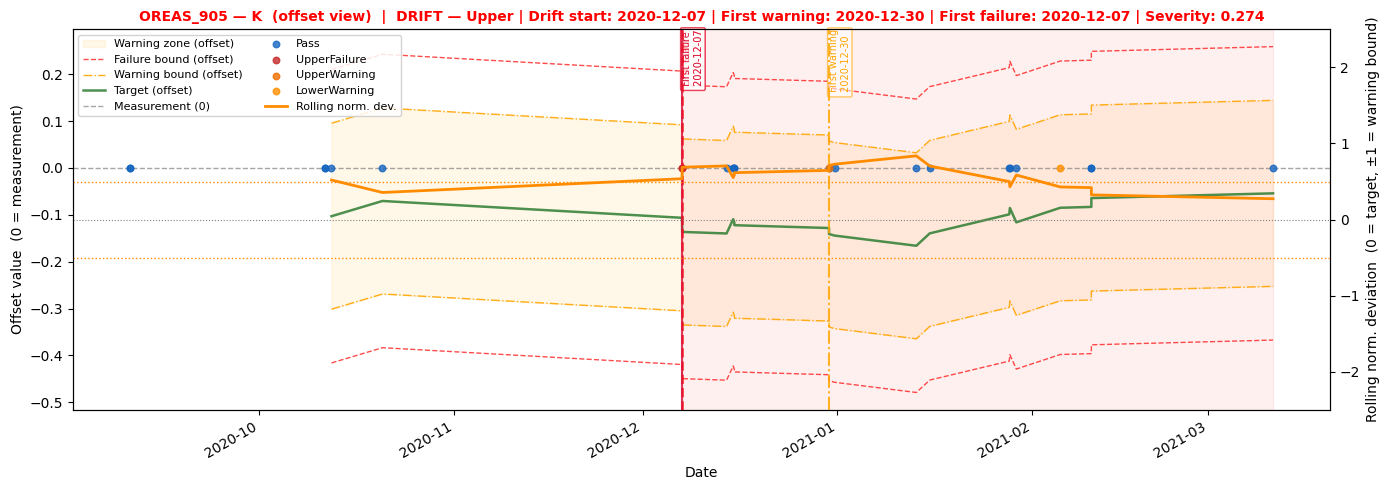

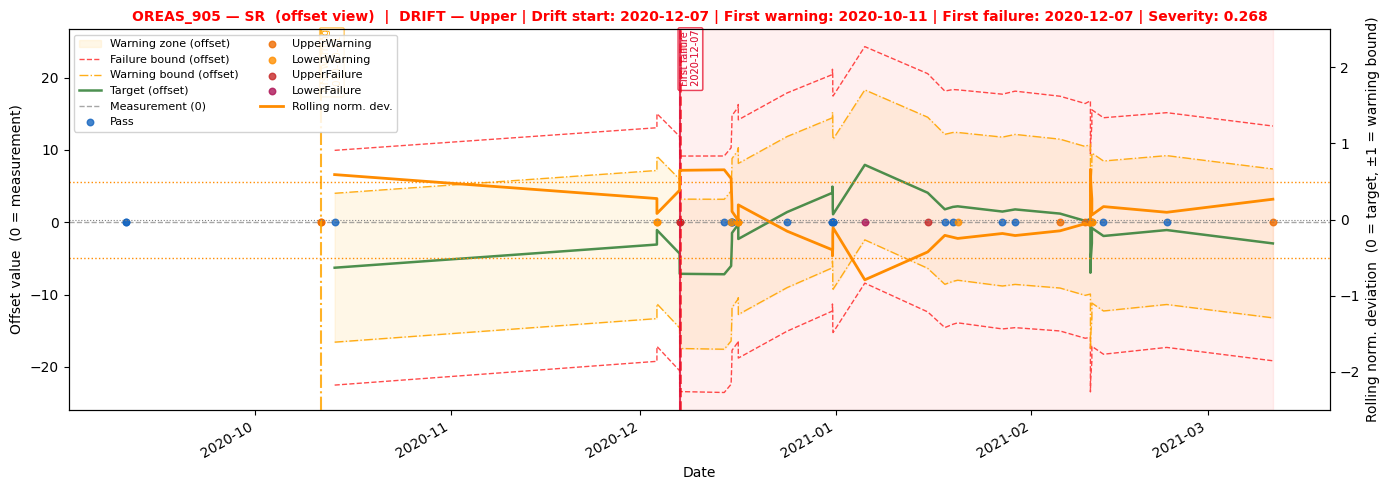

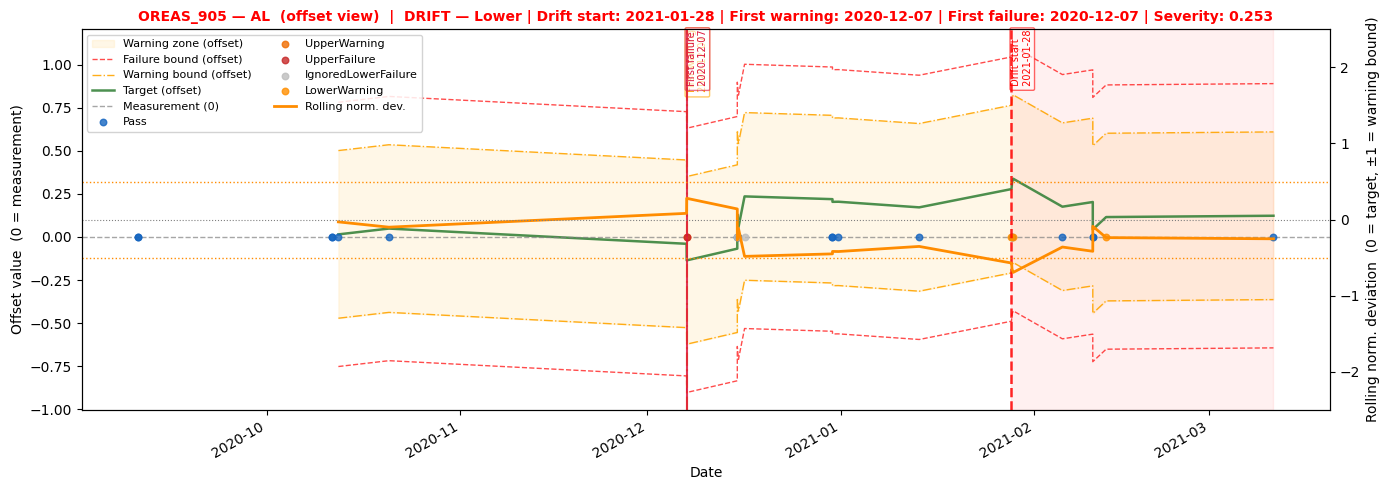

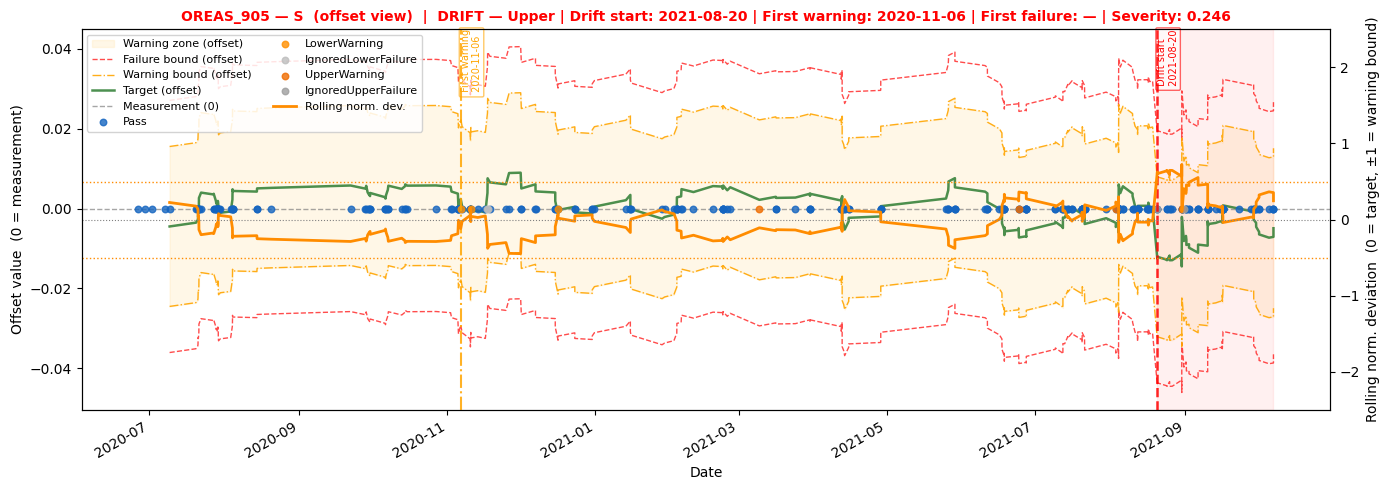

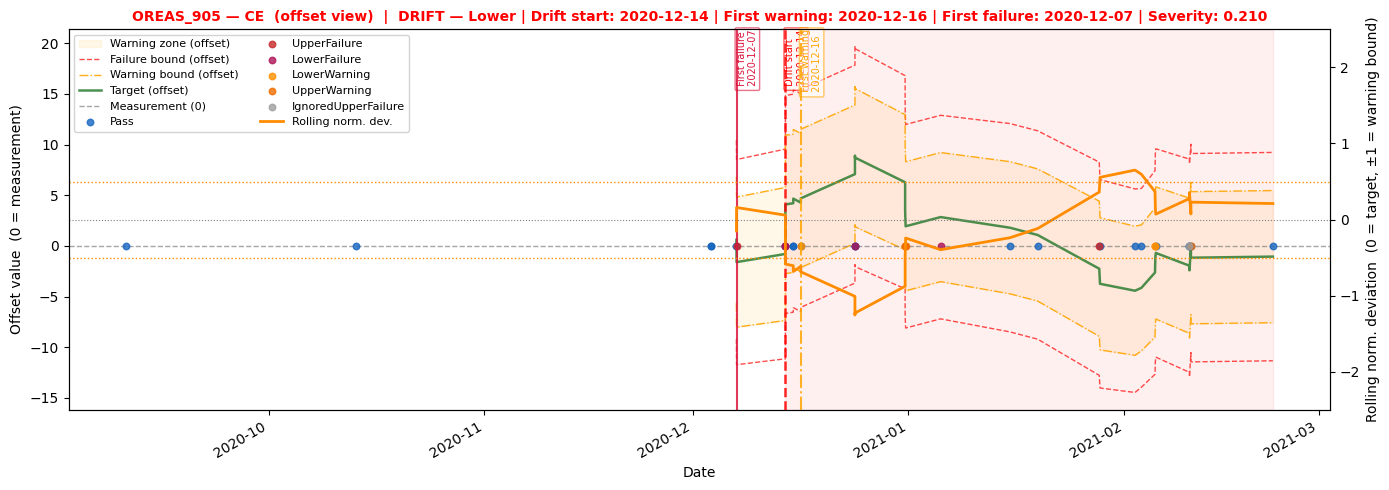

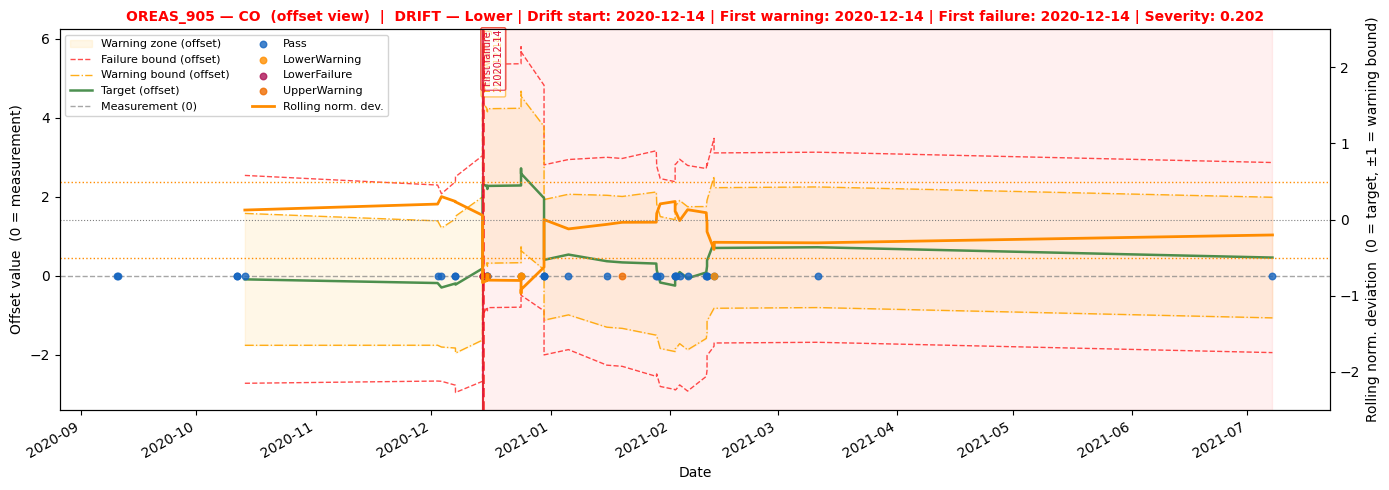

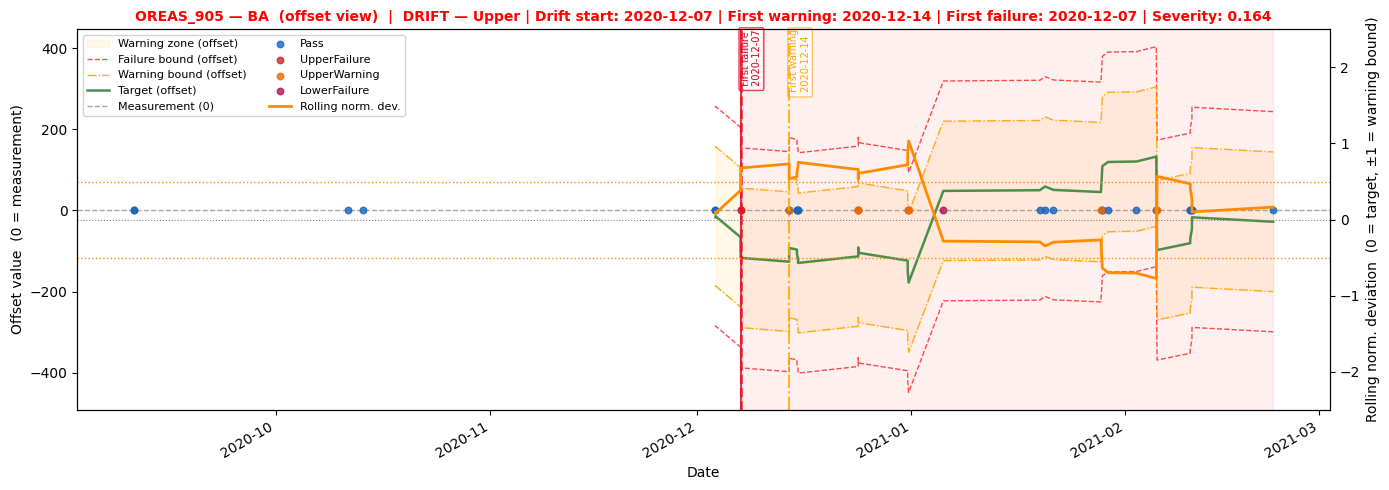

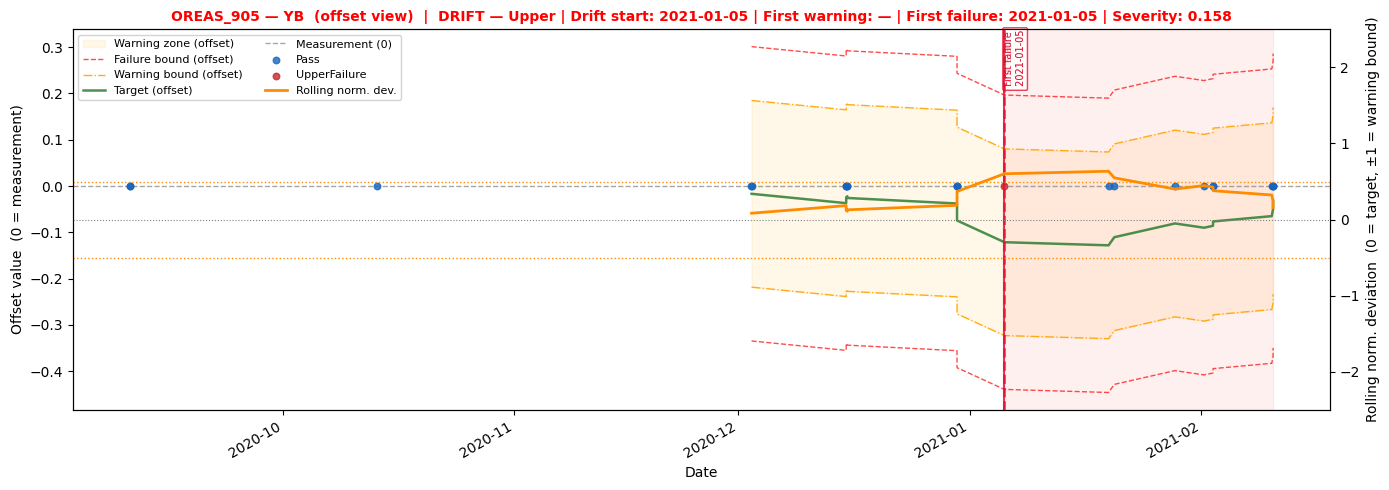

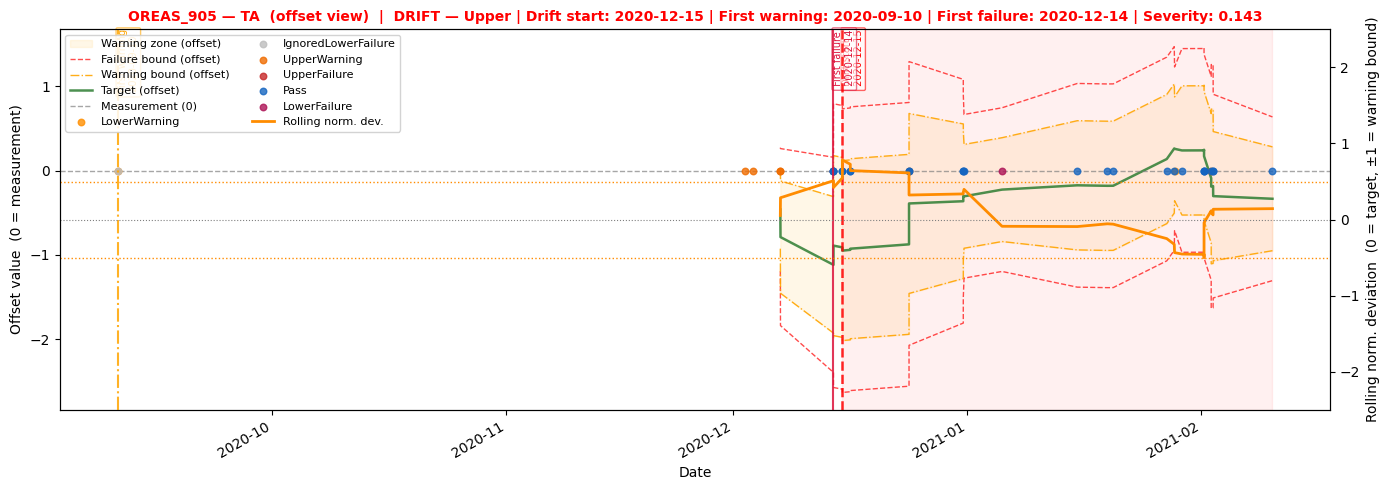

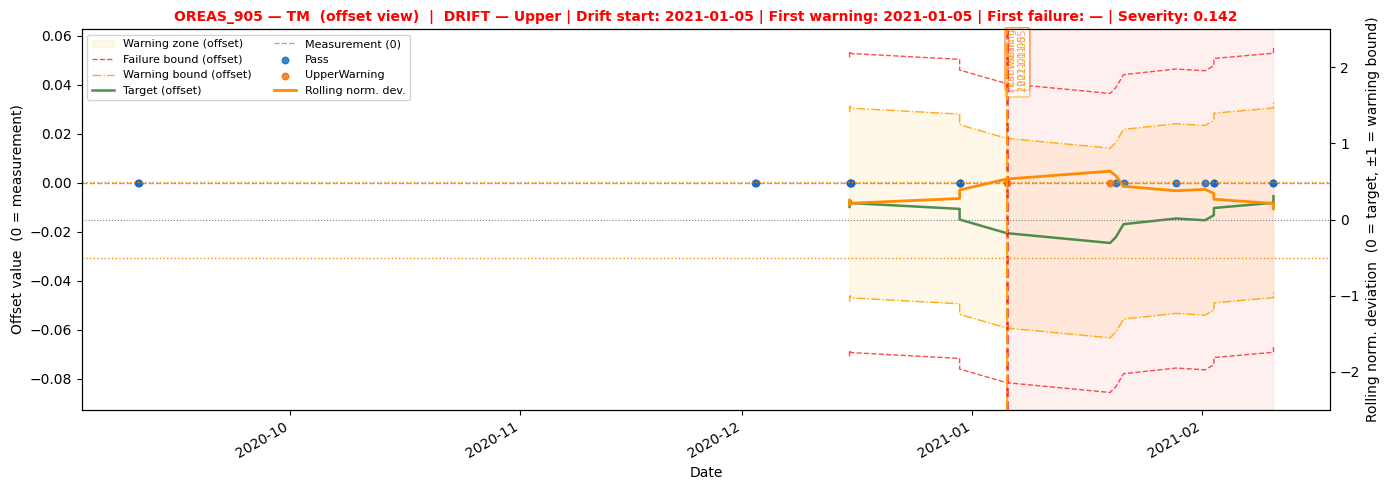

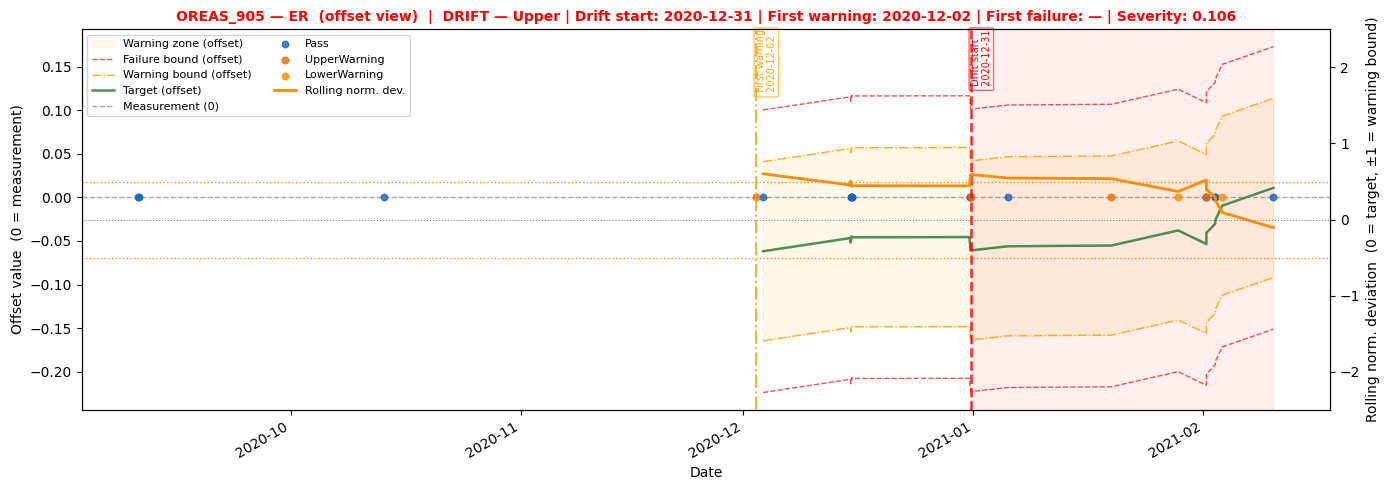

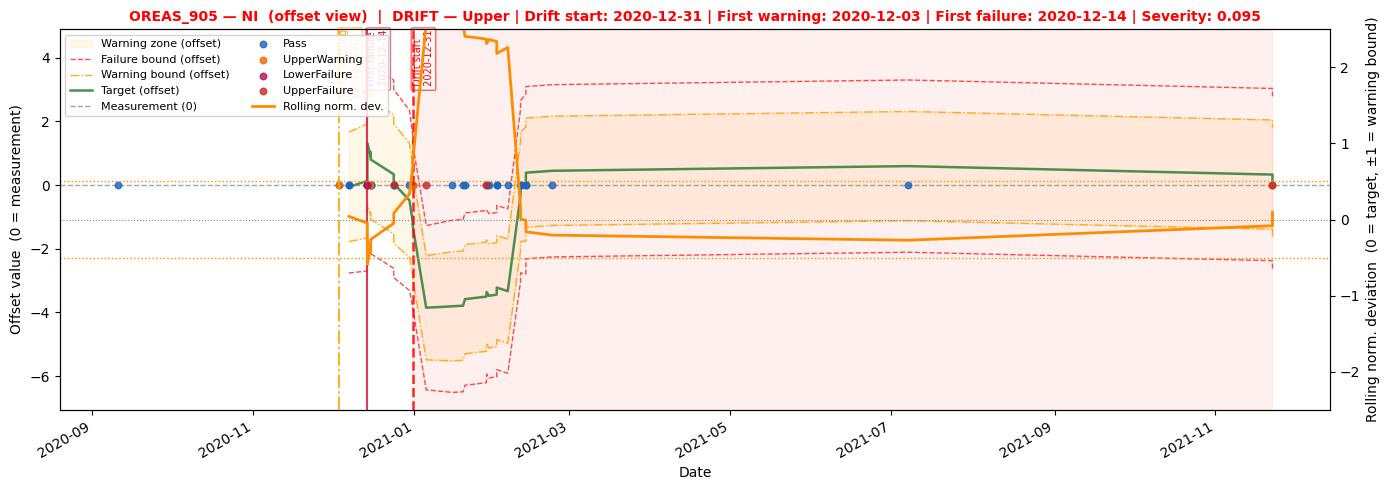

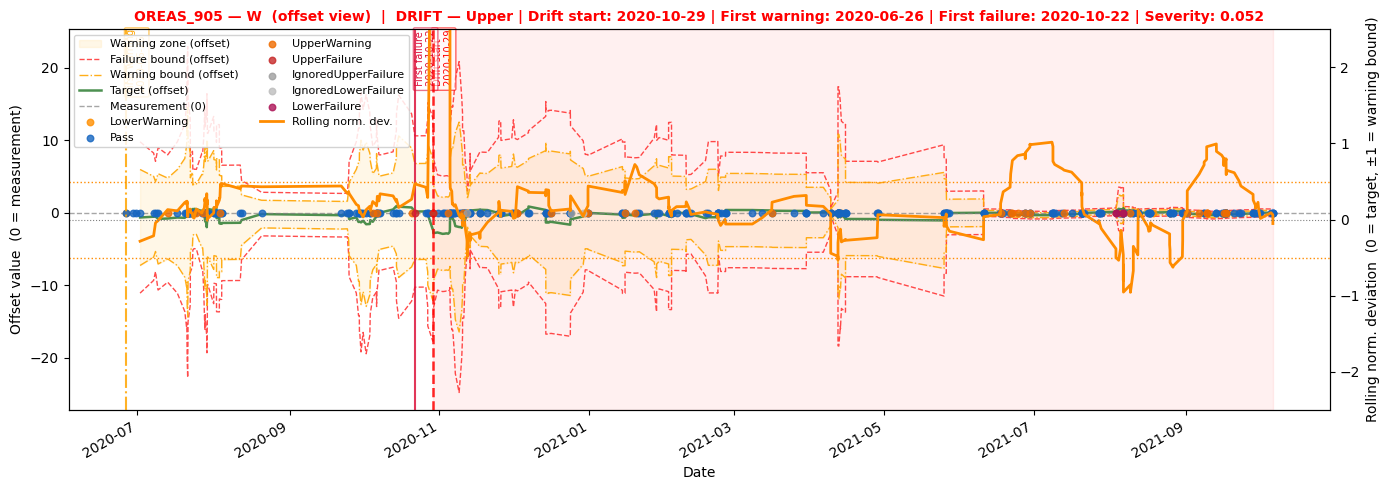

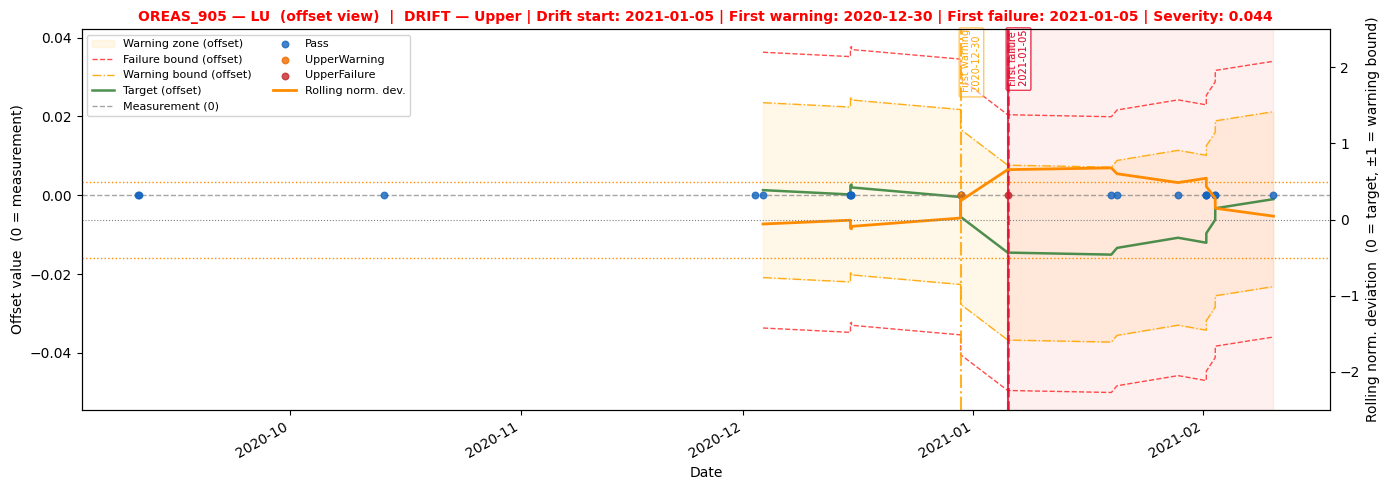

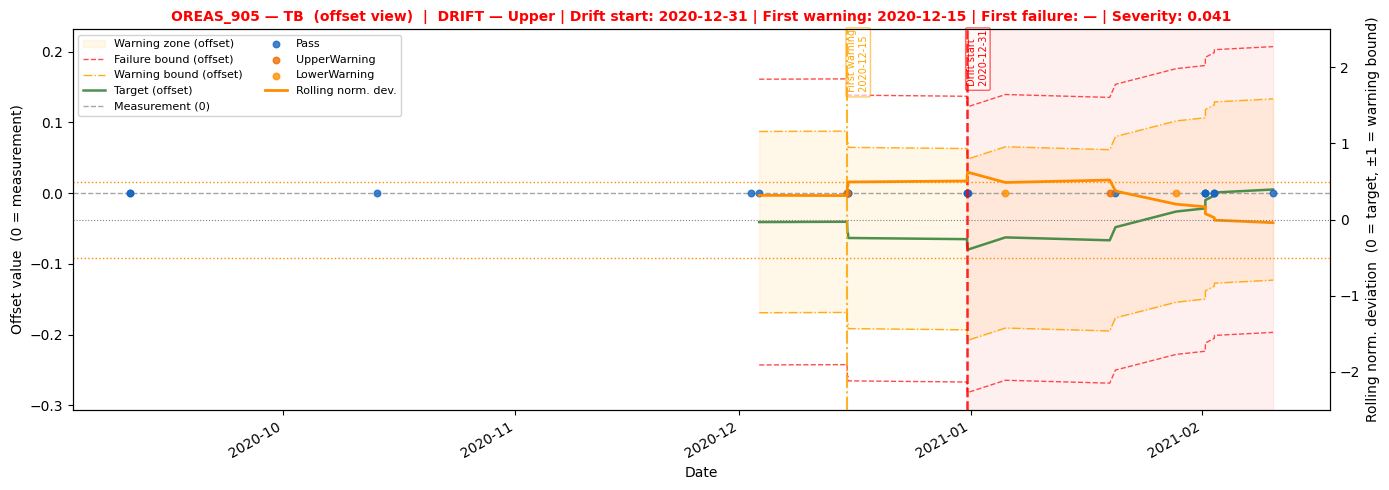

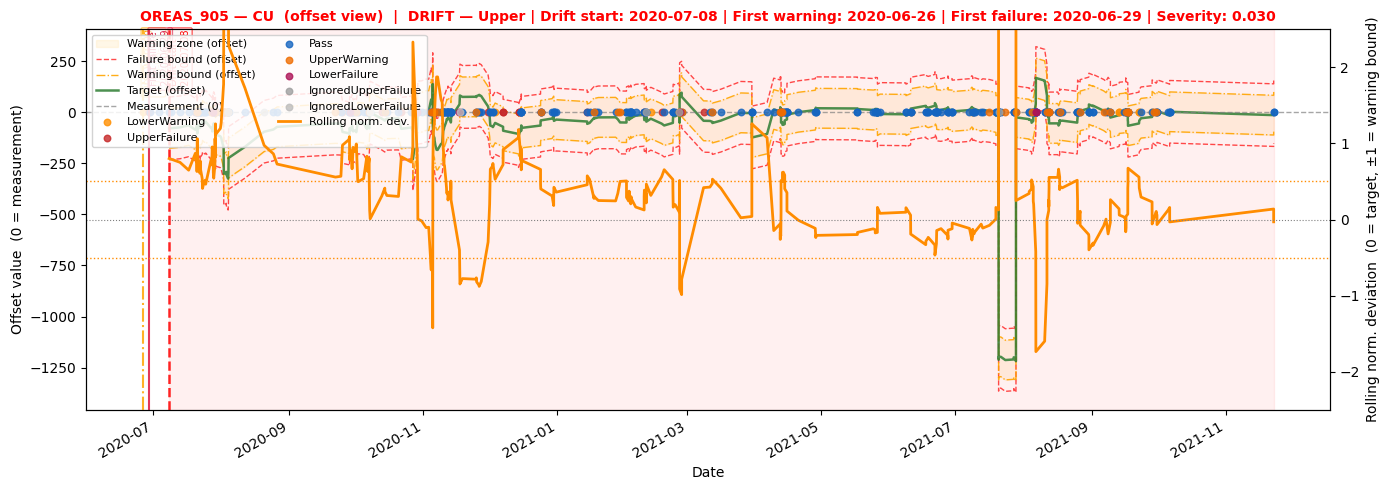

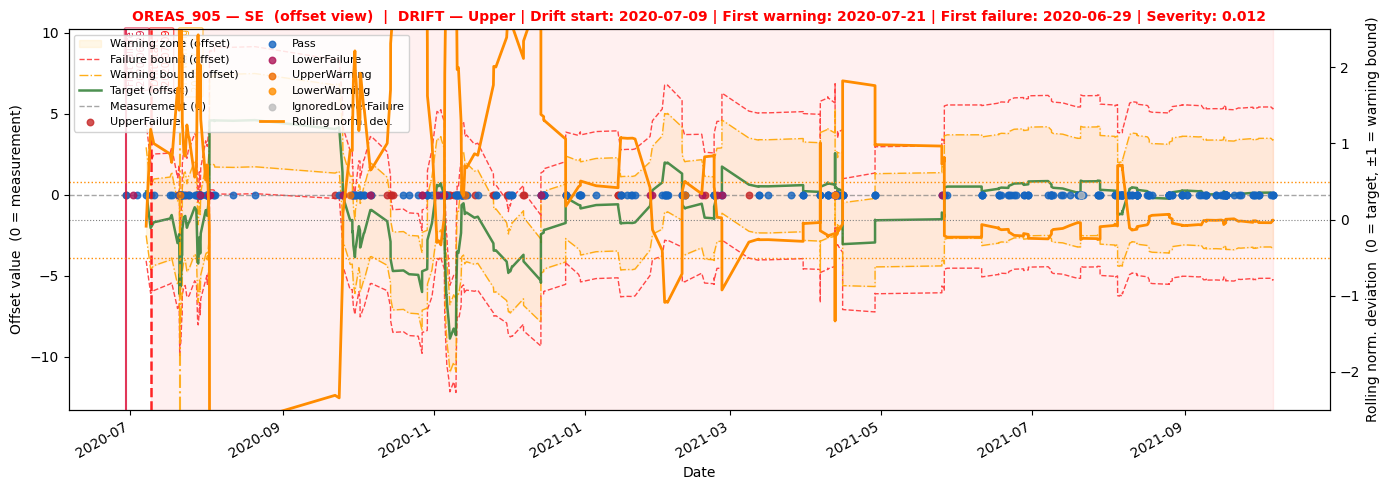

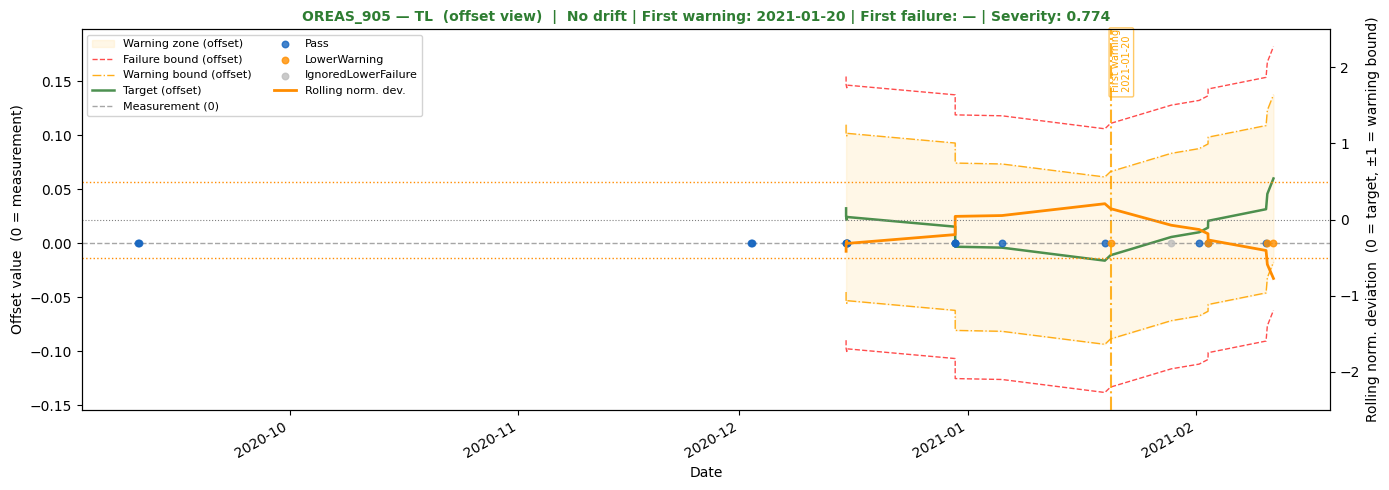

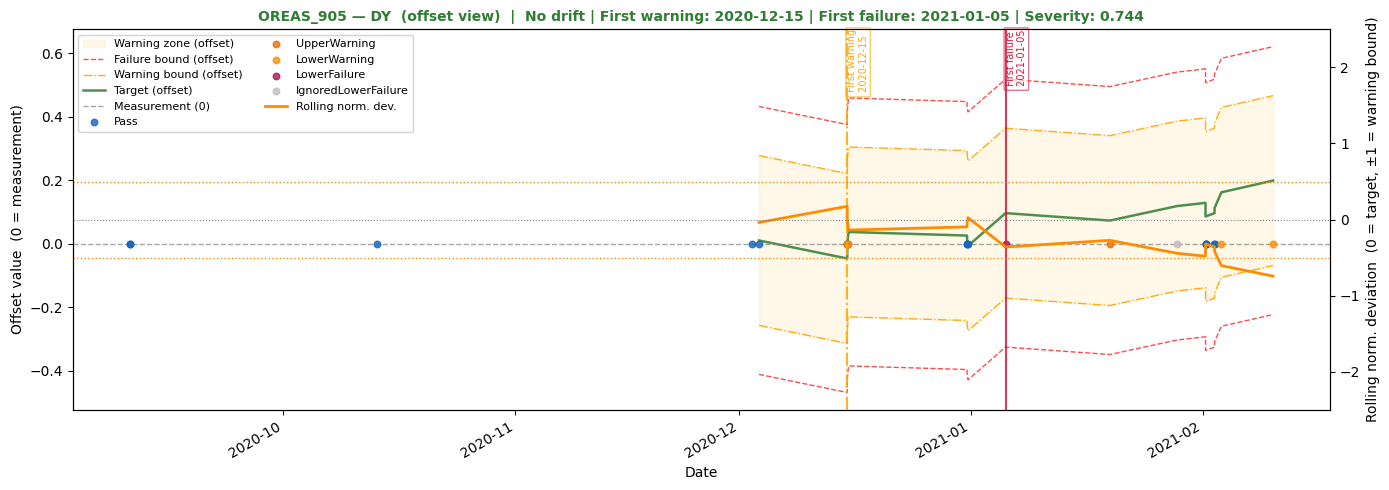

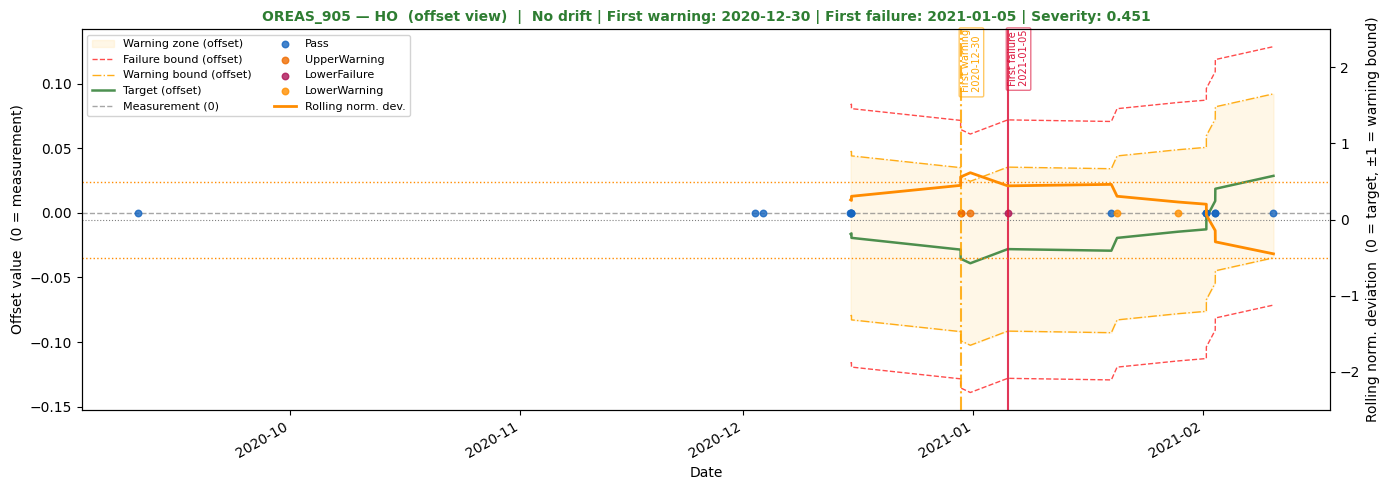

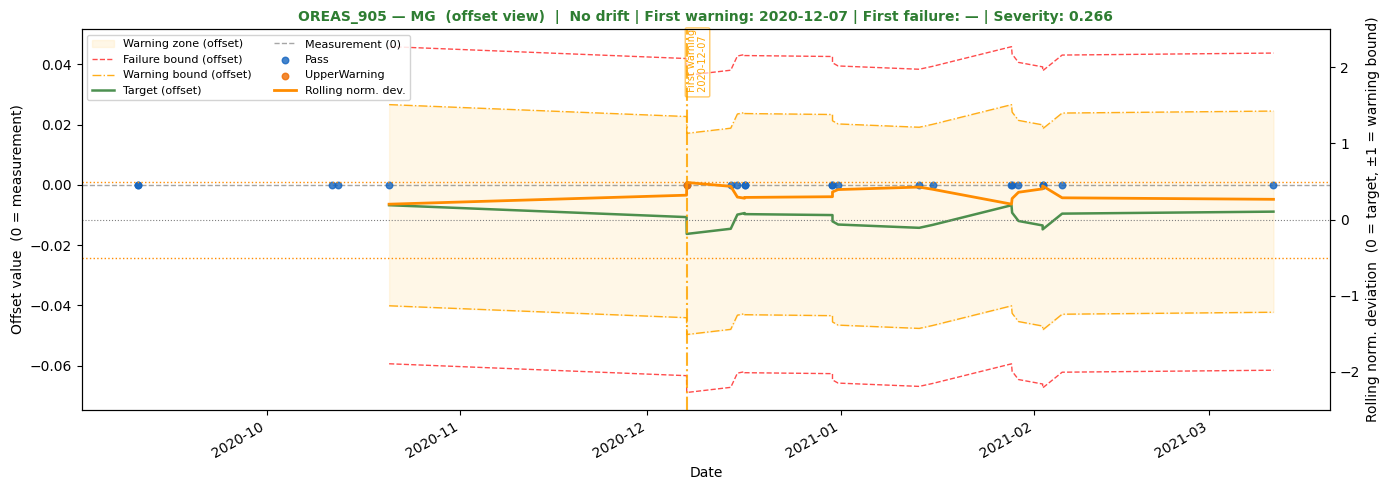

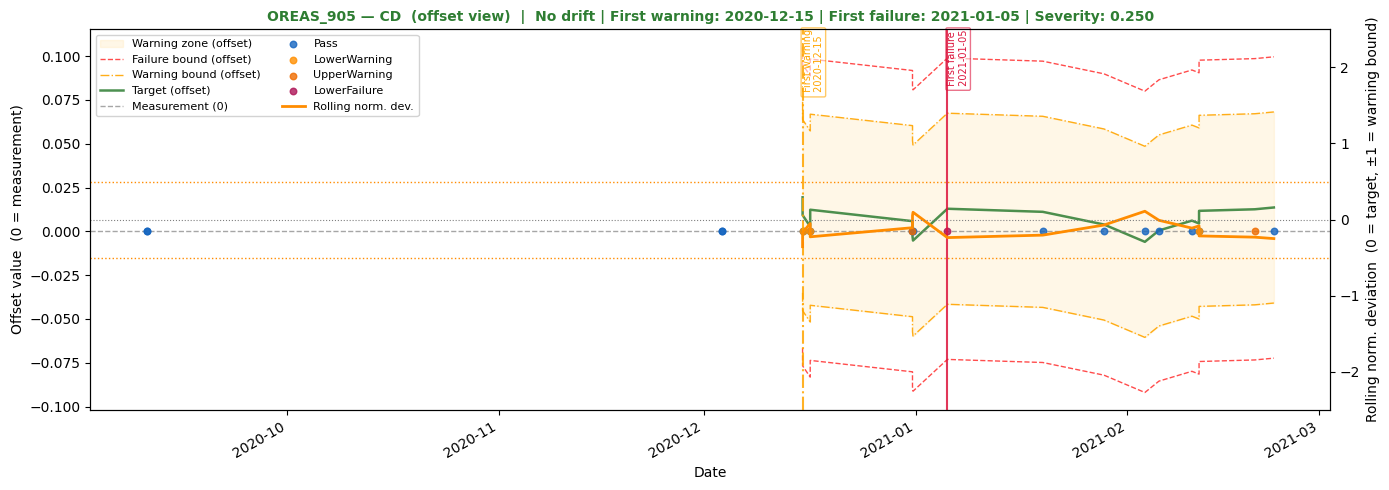

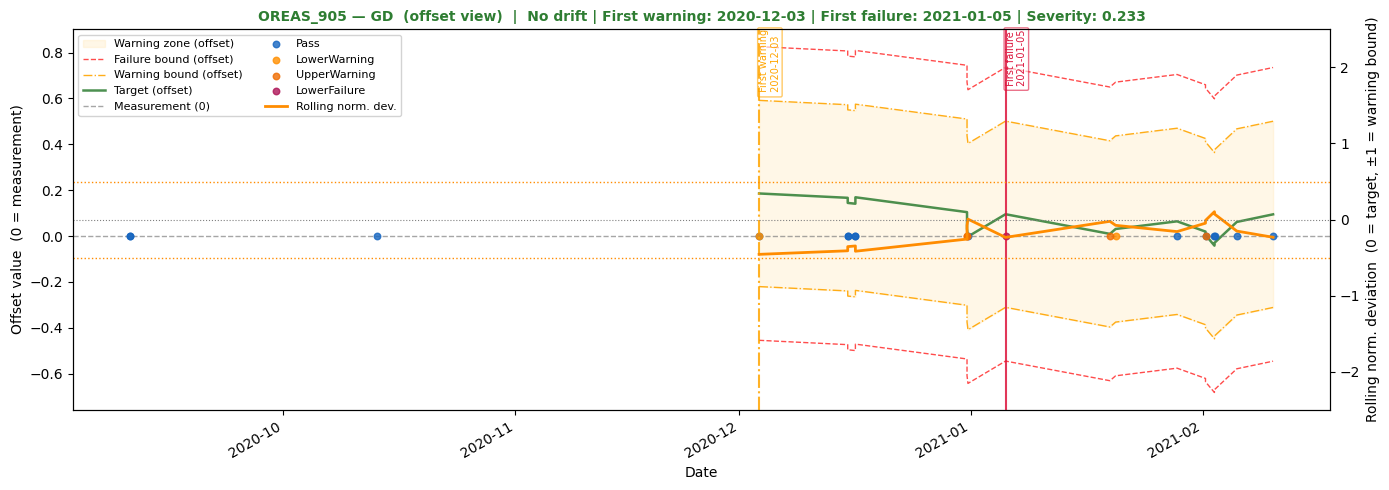

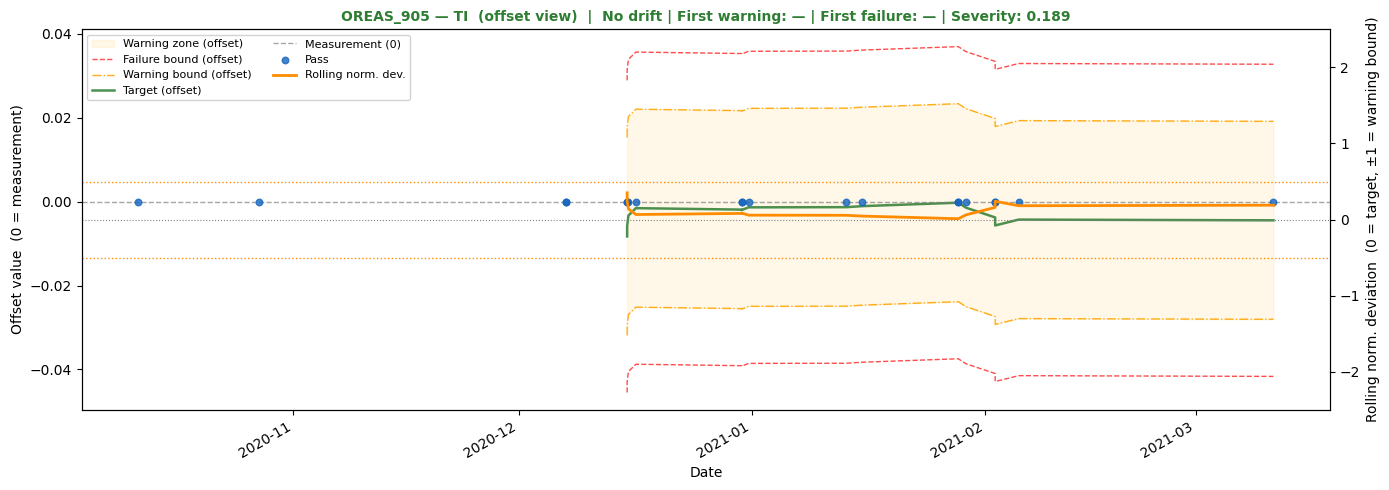

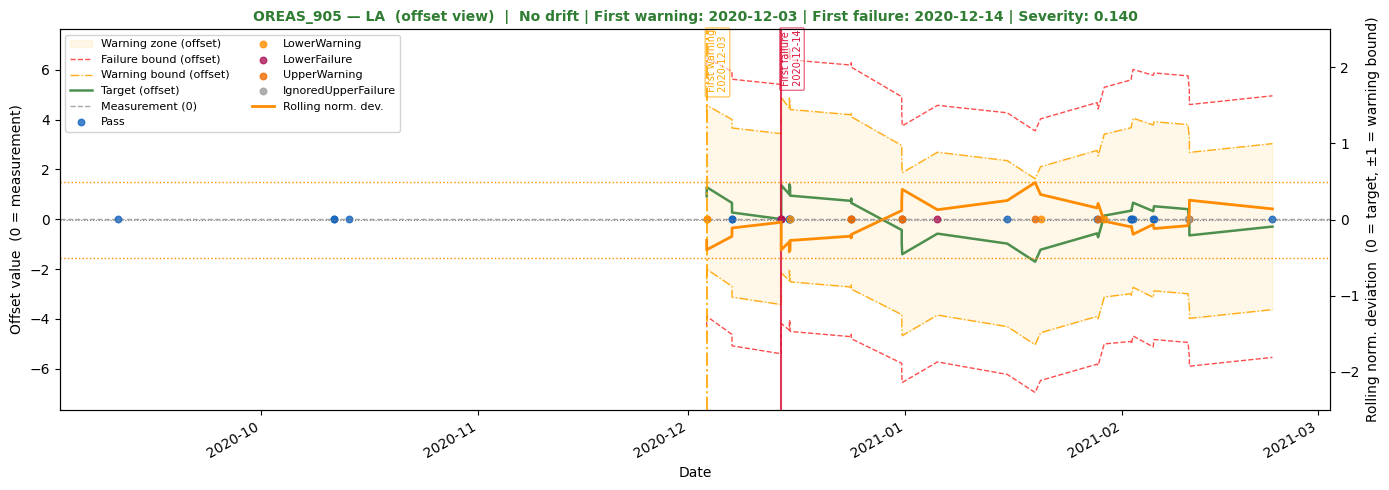

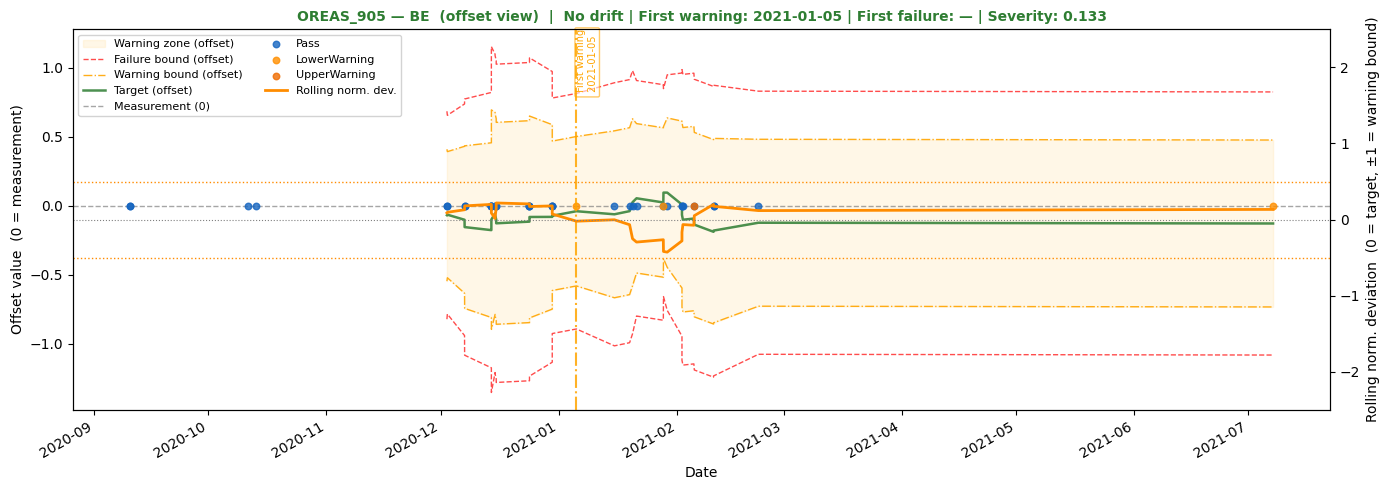

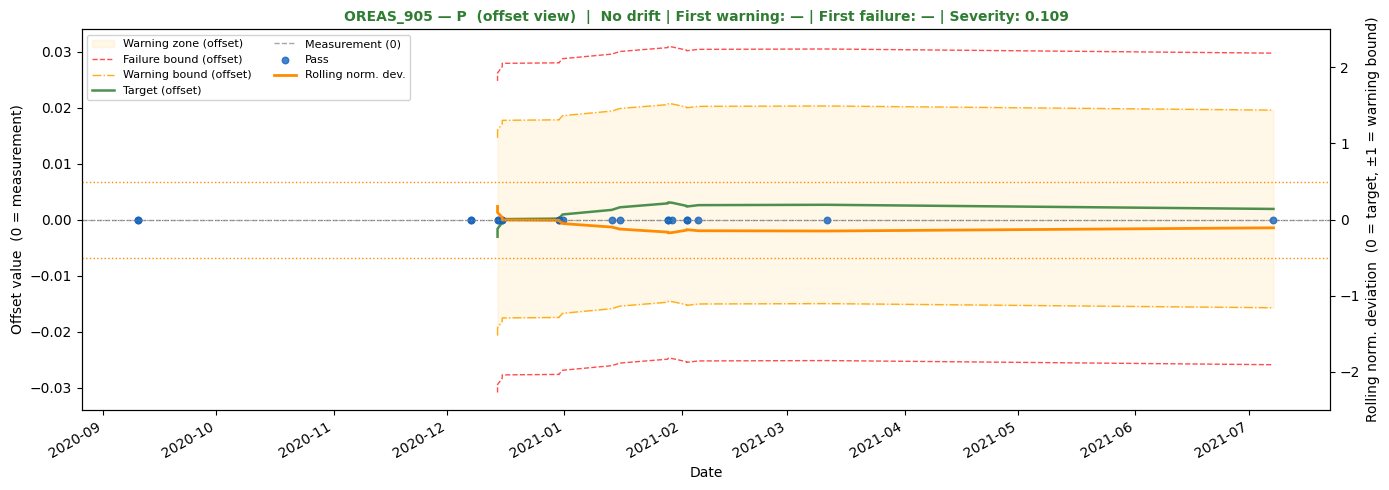

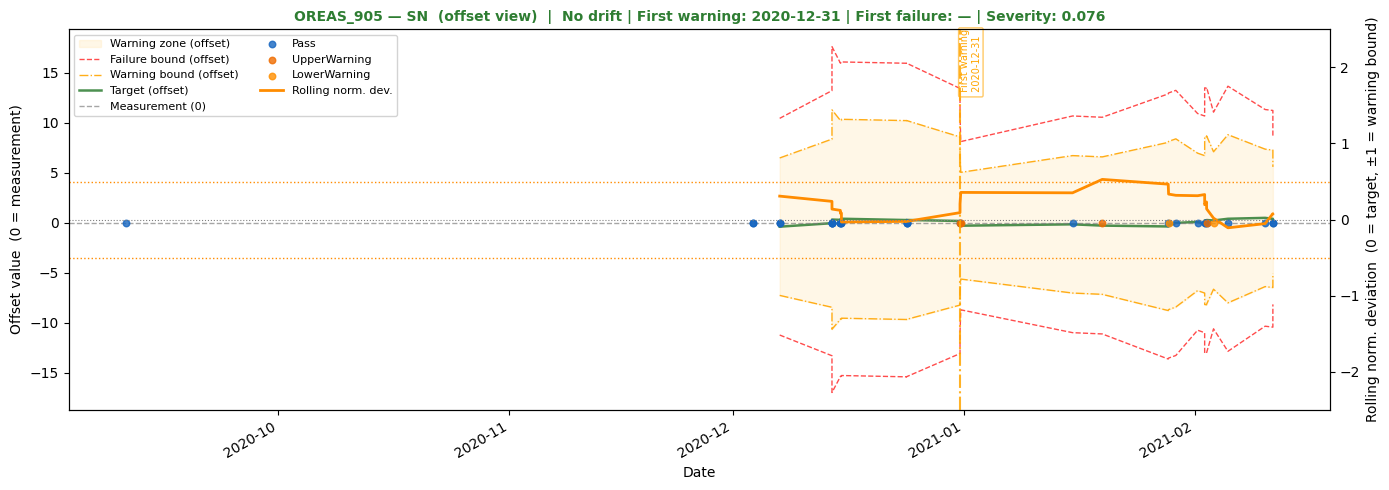

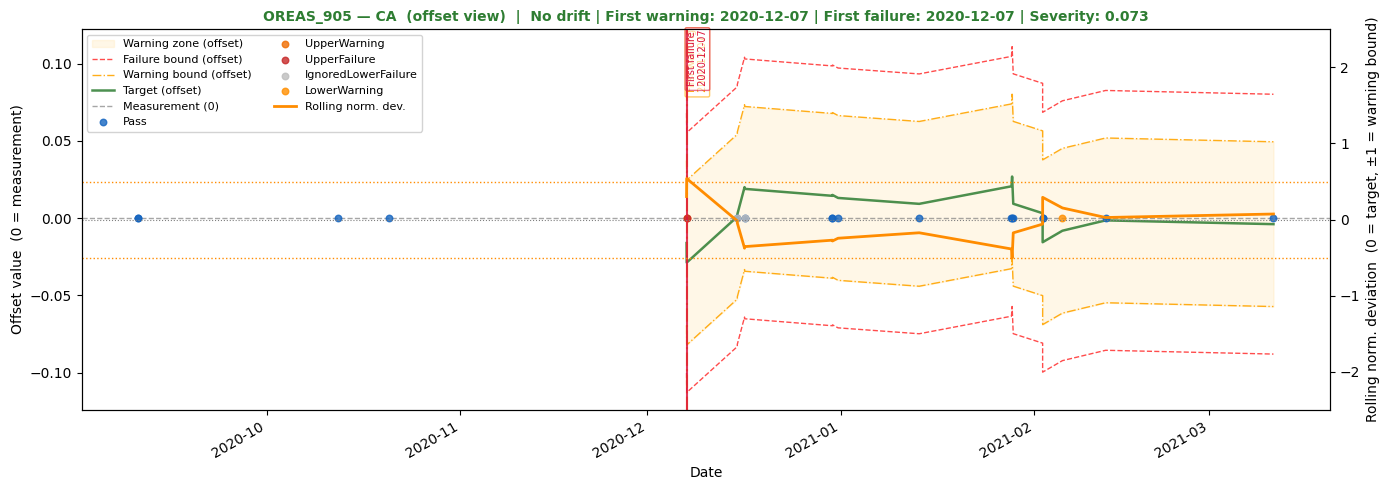

In [9]:
for _, row in summary.iterrows():
    analyte    = row["ANALYTE_CODE"]
    adf        = analyte_data[analyte]
    drift_info = row.to_dict()

    plot_analyte_offset(
        adf,
        analyte         = analyte,
        std_lot_code    = STD_LOT_CODE,
        drift_info      = drift_info,
        drift_threshold = DRIFT_THRESHOLD,
    )

## 7. Export Results

out_path = Path(f"drift_results_offset_{STD_LOT_CODE}.csv")
summary.to_csv(out_path, index=False)
print(f"Saved → {out_path}")